## Cosmic Watch Muon Detector
### Advised at the University of Pennsylvania
Author: Riley McManus
Start Date: 06/29/26
End Date: TBD
***


### Purpose
This notebook is used to analyze data collected with CosmicWatch muon detectors. It calculates coincidence rates across multiple orentations, looks at the effects of detector orientation on detection, estimates solid angle, and visually shows results with uncertainty.

### What is a Muon?
Muons are heavy subatomic particle created when cosmic ray reach Earth's atmosphere. Since muons travel close to the speed of light can penetrate large amounts of material, they are detectable using scintillation detectors.

### Acknowledgments
 This work builds upon the original code provided by the CosmicWatch project. The scripts and files were adapted from the CosmicWatch repository and have been modified for student use during a research internship. Additional edits, documentation, and analysis were created to have a reproducible notebook for student use. 
 https://github.com/spenceraxani/CosmicWatch-Desktop-Muon-Detector-v3X?tab=readme-ov-file
***

## The Cosmic Watch Muon Detector

I ran all three avalible versions of the Cosmic Watch scripts that import data, and none have the appropriate amount of categories. For some unexplained reason, there are more data categories than needed. Version one and version 3 produces proper headers. Version 3 is advised because it runs in python 3 and this notebook is written with that in mind. Since this Cosmic Watch is an older version, version 1 works also once the script is editted to run in Python 3.

**Note**: Edited versions of the CosmicWatch scripts that wotrk with Python 3 are available in the GitHub repository. The changes are written below, but manual editting isn't needed, unless files are coming from the official Cosmic Watch repository.

1. install pyserial
    - Make sure to run pip uninstall serial before running pip install pyserial, otherwise Python will provide an AttributeError.
 
 For V3 of Cosmic Watch:
   - Download import_data.py (the version three script) from the GitHub repository 


For V1 of Cosmic Watch:
     - Download import_signal.py (the version one script) from the GitHub repository 

If running on Python 3:
   - Open the script and change lines 59, 72, and 73 from raw_imput to imput
        - Example: ArduinoPort = raw_input("Select Arduino Port:") to ArduinoPort = input("Select Arduino Port:")
        - Will produce NameError: name 'raw_input' is not defined
   - Open the script and remove 0 from line 86
        - Example: file = open(fname, "w")
   - Open the script and edit line 98 to  file.write(str(datetime.now())+" "+data.decode("utf-8"))
        - Will produce Error: can only concatenate str (not "bytes") to str 
        - Use .decode("utf-8") to convert bytes to str

        
2. If you are Mac user, you will need to install the CH340g driver to read from serial port.

3. Run python import_signal.py (V1) or import_data.py (V3)

***
You should see: 
Welcome to CosmicWatch: The Desktop Muon Detector
Available serial ports:

Enter:
- **File name** - The data will be saved in the file you name (ex. muon_data.txt for V1 and CW_data.txt for V3)
- **Device ID** - Device ID shows which detector was used to collect the data

***

If connecting to the server www.cosmicwatch.lns.mit.edu
1. Download detector_server.py from the GitHub repository and run with python 
2. If running on Python 3:
	Open the script:
	- Change import thread to import _thread as thread
		- Python changed thread to _thread
	- Change the indentation on line 57 by tabing "print"
	- Change the indentation on line 68 by ensuring "print" is indented and not spaced
	-  Ensure lines 91, 101, 104, 106, 109, 118, 119, 152, and 153 say print('') and not  print''
	- Change line 151 to your IP
		- Localhost address so the computer can to refer to itself
	- Move the closing parenthesis to the end of line 152
	- Remove io_loop = mainLoop from line 156
3. open www.cosmicwatch.lns.mit.edu start-measurement. 

In [137]:
# Imports
import glob
import sys
import pylab
from pylab import *
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import time
import pandas as pd
import numpy as np
import os

#### Hardware Setup:
The two CosmicWatch detectors are connected to the computer through a USB connector with micro-USB connections for each detector. The detectors are connected to each other using a coaxial coincidence cable, which allows the detectors to record events detected at the same time by both.

The detectors are set up specifcally for each orientation measurement. In Orientation 0, the detectors are stacked directly on top of each other with the faces up to have the largest detector acceptance area.

To enable coincidence mode, the top detector must be restarted first so that it goes into master mode. The bottom detector is then restarted. Once this is done, the data will show both coincident and non-coincident events. The coincidence column will show 1's and 0's. 1's are coincident events and 0's are non-coincident events.

#### Note on Detector Orientations
Each detector orentation file is named after the orientation used to collect data.

- **CW_data1.txt** – Orientation 0: detectors stacked directly on top of each other with faces up (at home).
- **CW_data1lab.txt** – Orientation 0 recorded in the laboratory for comparison.
- **CW_data1lead.txt** - Orientation 0 with 3 lead blocks surrounding the detectors.
- **CW_datao1.txt** – Orientation 1: detectors stacked directly on top of each other with faces sideways.
- **CW_datao2.txt** – Orientation 2: detectors have a 3.75 inch block inbetween with the faces sideways.
- **CW_datao3.txt** – Orientation 3: detectors have a 6 inch inch block inbetween with the faces sideways.
- **CW_datalead.txt** – Orientation 0 with a 2-inch (5.08 cm) lead block inbetween the detectors.
- **CW_2inch.txt.txt** - Orientation 0 with a 2-inch (5.08 cm) stand-in block placed between the detectors.

Additional orentations to examine relationship between coincidence rate and solid angle:
- **CW_data35.txt** – Orientation 0: detectors stacked directly on top of each other with 3.5 inches (8.89 cm) inbetween.
- **CW_data12.txt** – Orientation 0: detectors stacked directly on top of each other with 12 cm inbetween.

While files can be named at user discretion, these file names are used in the notebook for plots, calculations, and analysis. 
***

### Section 1: CW_data1.txt and CW_data1lab.txt (Orentation 0 in coincidence mode)
#### Loading and cleaning data, establishing coincidence mode and SiPM vs. Time graph.
Two Orientation 0 datasets are used because the measurements throughout the notebook were done in two locations, at home and in the lab. 
CW_data1.txt and CW_data1lab.txt are both anaylized to have a reference for location differences in later analysis.
***


In [16]:
# To ensure the file loads and pandas puts it into columns, use:
# data = pd.read_csv("muon_data.txt", sep=r"\s+", skiprows=5, header=None)
    # sep=r"\s+" speficies that the columns are separated by whitespace
    # skiprows=t, header=None ensures pandas skips the first 5 rows, the header, and starts reading the data after.

data1 = pd.read_csv("CW_data1.txt", sep=r"\s+", skiprows=5, header=None)
data1lab = pd.read_csv("CW_data1lab.txt", sep=r"\s+", skiprows=5, header=None)

# Run data1.shape to see if the data is sorted in to one or multiple columns
print(data1.shape)
print(data1lab.shape)

# There should be 15 columns in the data file. 14th columns are used for the data 
# and the 15th column is a placeholder date column that will be dropped. 
# The data will be cleared to 10 necessary columns for coincidence data analysis.

(60293, 15)
(1702, 15)


Load and organize the Orientation 0 (home) dataset. The cleaned data is saved as a new file.
The same data-cleaning procedure is repeated after for the Orientation 0 data recorded in the lab.

In [17]:

import pandas as pd

# Load the data file so all 13 columns are present
data1 = pd.read_csv("CW_data1.txt", sep=r"\s+", skiprows=5, header=None)

# Rename the columns: 
# If the name of the device is two words, assign 2 name columns to data1 
# because the name of the device registering the data is being split into two columns.

data1.columns = [
    "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    "SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel(X:Y:Z)[g]", "Coincidence", 
    "Name1", "Name", "Comp_time", "Comp_date"
]

# If NOT in coincidence mode use:  
# data2.columns = [
    # "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    #"SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel_XYZ", 
    #"Gyro_XYZ", "Name1", "Name", "Comp_time", "Comp_date"
#]

# Keep 10 columns. Keep 9 columns if the not using coincidence data.
# Must put it in the order the notebook expects, not the order they are in the original data file. 
cols_keep = [
    "Comp_date",
    "Comp_time",
    "Event",
    "Ardn_time",
    "ADC_value",
    "SiPM_mV",
    "Deadtime_ms",
    "Temp_C",
    "Name",
    "Coincidence"
]

# Select only the columns we want to keep by running data1 = data1[cols_keep] 
# (data1 is a placeholder for the name you assigned the file)
data1 = data1[cols_keep]

# Save cleaned dataset as a 10-column text file with space-separated values 
# so it matches the format required by CWClass (CosmicWatch notebook)
data1.to_csv("CW_data_10col1.txt", sep=" ", index=False, header=False)

# If NOT using coincidence data:
# data1.to_csv("CW_data_9col1.txt", sep=" ", index=False, header=False)

# Test to check column names and that the constant date column was dropped.
print(data1.head())

    Comp_date        Comp_time  Event    Ardn_time  ADC_value  SiPM_mV  \
0  15/07/2026  22:00:24.733868     44  0:16:23.696      925.0    136.0   
1  15/07/2026  22:00:25.641815     45  0:16:24.604      218.0      8.0   
2  15/07/2026  22:00:26.113286     46  0:16:25.076      175.0      9.0   
3  15/07/2026  22:00:26.236573     47  0:16:25.199      183.0      7.0   
4  15/07/2026  22:00:26.960903     48  0:16:25.923      180.0      8.0   

   Deadtime_ms  Temp_C         Name  Coincidence  
0        36.92   26.96  Payne-Scott            0  
1         9.69   26.96  Payne-Scott            0  
2         8.70   26.96  Payne-Scott            0  
3         8.89   26.96  Payne-Scott            0  
4         8.82   26.96  Payne-Scott            0  


In [18]:
# Run the same code to organize o0 data recorded in the lab

data1lab = pd.read_csv("CW_data1lab.txt", sep=r"\s+", skiprows=5, header=None)

data1lab.columns = [
    "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    "SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel(X:Y:Z)[g]", "Coincidence", 
    "Name1", "Name", "Comp_time", "Comp_date"]

cols_keep = [
    "Comp_date",
    "Comp_time",
    "Event",
    "Ardn_time",
    "ADC_value",
    "SiPM_mV",
    "Deadtime_ms",
    "Temp_C",
    "Name",
    "Coincidence"
]

# Select only the columns we want to keep by running data1 = data1[cols_keep] 
# (data1 is a placeholder for the name you assigned the file)
data1lab = data1lab[cols_keep]

# Save cleaned dataset as a 10-column text file with space-separated values 
# so it matches the format required by CWClass (CosmicWatch notebook)
data1lab.to_csv("CW_data_10collab.txt", sep=" ", index=False, header=False)


In [19]:
# ***********************************************************************************
# CWClass
# This class is used to import CW data and use it easily. 
# This class is taken and editted from the original repositiory notebook 
#
# Note: 
# bin_size: When plotting rate as a function of time, you need to specify the rate over
# a given interval. "bin_size" is the interval in seconds. Default is 60s.
#***********************************************************************************

class CWClass():
    def __init__(self,fname,bin_size = 30):
        self.name = fname.split('/')[-1]
        self.bin_size = bin_size
        
        fileHandle = open(fname,"r" )
        lineList = fileHandle.readlines()
        fileHandle.close()
        header_lines = 0
        
        # Look through the first 1000 lines for the word "Device". Everything prior is considered part of the header.
        for i in range(min(len(lineList),1000)):
            header_in_file = lineList[i]
            if 'Device' in header_in_file:
                header_lines = i+1
  
        #Determine number of columns by looking at the second last line in the file.
        number_of_columns = len(lineList[len(lineList)-2].split(" "))
        column_array = range(0,number_of_columns)

        
        file_from_computer = False
        file_from_sdcard   = False
        
        if number_of_columns == 10:
            file_from_computer = True  # If you have 10 columns, you probably took the data on the computer 
            data = np.genfromtxt(fname, dtype = str, delimiter=' ', usecols=column_array, invalid_raise=False, skip_header=header_lines)
            comp_date = data[:,0] #first column of data
            comp_time = data[:,1]
            event_number = data[:,2].astype(float)
            # The column contained formatted time strings (HH:MM:SS.ms) instead of numeric values.
            # It had to be manually converted to milliseconds for processing.
            Ardn_time_ms = np.array([
                int(t.split(":")[0])*3600 +
                int(t.split(":")[1])*60 +
                float(t.split(":")[2])
                for t in data[:,3]
                ]) * 1000
            adc = data[:,4].astype(float)
            sipm = data[:,5].astype(float)
            deadtime = data[:,6].astype(float)
            temperature = data[:,7].astype(float)
            # Ensure lines say (float) instead of (np.float)
            detName = data[:,8]
            self.coincidence = data[:,9].astype(float) 


            
        elif number_of_columns == 6:
            file_from_sdcard = True # If you have 6 columns, you took the data from the sdCard
            data = np.genfromtxt(fname, dtype = str, delimiter=' ', usecols=column_array, invalid_raise=False, skip_header=header_lines)
            event_number = data[:,0].astype(np.float)
            Ardn_time_ms = data[:,1].astype(np.float)
            adc = data[:,2].astype(np.float)
            sipm = data[:,3].astype(np.float)
            deadtime = data[:,4].astype(np.float)
            temperature = data[:,5].astype(np.float)
            
        else: 
            print('The file format is unknown, or older. If it is an older file format, you will have to change the number of columns in the CW class.')
            
            
        # Simple check to see if the events are sequential
        def sequential(l):
            l = np.asarray(l).astype(int)
            check = range(min(l),max(l)+1)

            if len(l)!=len(check):
                print('There is an event missing in the data.')
                return False

            counter = 0
            for i in range(len(l)):
                counter+=1
                if l[i]!=check[i]:
                    print('Check event number: '+str(counter))
            return sum(check == l)==len(l)

        if not sequential(event_number):
            print('Events in file are not sequential.')

        # Convert the computer time to an absolute time (MJD).
        if file_from_computer:
            time_stamp = []
            for i in range(len(comp_date)):
                comp_date = [d.replace('/', '-') for d in comp_date]
                day  = int(comp_date[i].split('-')[0])
                month = int(comp_date[i].split('-')[1])
                year   = int(comp_date[i].split('-')[2])
                hour  = int(comp_time[i].split(':')[0])
                mins  = int(comp_time[i].split(':')[1])
                sec   = int(np.floor(float(comp_time[i].split(':')[2])))
                try:  
                    decimal = float('0.'+str(comp_time[i].split('.')[-1]))
                except:
                    decimal = 0.0
                time_stamp.append(float(time.mktime((year, month, day, hour, mins, sec, 0, 0, 0)))+ decimal) 


            self.time_stamp_s     = np.asarray(time_stamp) -  min(np.asarray(time_stamp))       # The absolute time of an event in seconds
            self.time_stamp_ms    = np.asarray(time_stamp -  min(np.asarray(time_stamp)))*1000  # The absolute time of an event in miliseconds   
            self.total_time_s     = max(time_stamp) -  min(time_stamp)     # The absolute time of an event in seconds
            self.detector_name    = detName                                
            self.n_detector       = len(set(detName))

        # Convert the cumulative deadtime to the deadtime between events
        # The detector starts at time 0, so append a zero.
        event_deadtime_ms = diff(np.append([0],deadtime))

        # The Arduino absolute time isn't great. Over the course of a few hours, it will be off by several seconds. 
        # The computer will give you accurate time down to about 1ms. Reading from the serial port has ~ms scale uncertainty.
        # The Arduino can give you a precise measurement (down to 1us), but the absolute time will drift. Expect it to be off by roughly 1min per day.
        from datetime import datetime
        

        self.Ardn_time_ms      = Ardn_time_ms
        self.Ardn_time_s       = Ardn_time_ms/1000.
        
        self.Ardn_total_time_s = max(self.Ardn_time_s)
        self.Ardn_total_time_ms= max(self.Ardn_time_s)*1000.

        self.event_number     = np.asarray(event_number)  # an arrray of the event numbers
        self.total_counts     = max(event_number.astype(int)) - min(event_number.astype(int))
        self.adc              = adc         # an arrray of the measured event ADC value
        self.sipm             = sipm        # an arrray of the measured event SiPM value
        
        self.event_deadtime_s   = event_deadtime_ms/1000.      # an array of the measured event deadtime in seconds
        self.event_deadtime_ms  = event_deadtime_ms            # an array of the measured event deadtime in miliseconds
        self.total_deadtime_ms  = max(event_deadtime_ms)       # an array of the measured event deadtime in miliseconds
        self.total_deadtime_s   = max(event_deadtime_ms)/1000. # The total deadtime in seconds
                
        # The time between events is well described by the Arduino timestamp. 
        # The 'diff' command takes the difference between each element in the array.
        self.Ardn_event_livetime_s = diff(np.append([0],self.Ardn_time_s)) - self.event_deadtime_s
        

        if file_from_computer:
            self.live_time        = (self.total_time_s - self.total_deadtime_s)
            self.weights          = np.ones(len(event_number)) / self.live_time
            self.count_rate       = self.total_counts/self.live_time 
            self.count_rate_err   = np.sqrt(self.total_counts)/self.live_time 

            bins = range(0,int(max(self.time_stamp_s)), self.bin_size)
            counts, binEdges       = np.histogram(self.time_stamp_s, bins = bins)
            coincidence, binEdges  = np.histogram(self.time_stamp_s[self.coincidence == 1], bins = bins)
            bin_livetime, binEdges = np.histogram(self.time_stamp_s, bins = bins, weights = self.Ardn_event_livetime_s)

            self.binned_coincidence_counts = coincidence
            self.binned_coincidence_rate = coincidence / bin_livetime
        
        if number_of_columns == 10:
            file_from_computer = True
        
    
        else:
            print('Error')
        
        print('Count rate: '+str(np.round(self.count_rate,4)) +' +/- '+ str(np.round(self.count_rate_err,4)))
        
        bincenters = 0.5*(binEdges[1:]+ binEdges[:-1])
        
        self.bin_size          = bin_size
        self.binned_counts     = counts
        self.binned_counts_err = np.sqrt(counts)
        self.binned_count_rate = counts/bin_livetime
        self.binned_count_rate_err = np.sqrt(counts)/bin_livetime
        self.binned_time_s     = bincenters
        self.binned_time_m     = bincenters/60.

    
        
def plusSTD(n,array):
    xh = np.add(n,np.sqrt(np.abs(array)))
    return xh

def subSTD(n,array):
    xl = np.subtract(n,np.sqrt(np.abs(array)))
    return xl

def fill_between_steps(x, y1, y2=0, h_align='mid', ax=None,lw=2, **kwargs):
    # If no Axes opject given, grab the current one:
    if ax is None:
        ax = plt.gca()
    # First, duplicate the x values
    xx = x.repeat(2)[1:]
    # Now: the average x binwidth
    xstep = sp.repeat((x[1:] - x[:-1]), 2)
    xstep = sp.concatenate(([xstep[0]], xstep, [xstep[-1]]))
    # Now: add one step at end of row.
    xx = sp.append(xx, xx.max() + xstep[-1])

    # Make it possible to chenge step alignment.
    if h_align == 'mid':
        xx -= xstep / 2.
    elif h_align == 'right':
        xx -= xstep

    # Also, duplicate each y coordinate in both arrays
    y1 = y1.repeat(2)#[:-1]
    if type(y2) == sp.ndarray:
        y2 = y2.repeat(2)#[:-1]

    # now to the plotting part:
    ax.fill_between(xx, y1, y2=y2,lw=lw, **kwargs)
    return ax

print('Definitions complete ...')


Definitions complete ...


In [105]:
# Load data that was taken from a computer
cwd = os.getcwd()

# Make sure you use the 10-column text file that was created from the original data file. 
# The original data file has 14 columns, but the CWClass only works with 10 columns.

# This notebook has two data files of Orenation 0 (o0), one recorded at home and one in the lab. 
# Because of this, below has two lines defining 10 column files. 
file1 = CWClass(cwd + "/CW_data_10col1.txt", bin_size = 30)
file1lab=CWClass(cwd + "/CW_data_10collab.txt", bin_size = 30)

# Calculate the coincidence rate 
# Count how many ones are in the coincidence column (sum) and divide by the total time in seconds to get the coincidence rate in Hz.
# This is done for o0 at home and in the lab below
coincidence_rate = sum(file1.coincidence) / file1.total_time_s
print(coincidence_rate)  

coincidence_ratelab = sum(file1lab.coincidence) / file1lab.total_time_s
print(coincidence_ratelab)

Count rate: 1.5862 +/- 0.0065
Count rate: 1.386 +/- 0.0336
0.09960396749809468
0.12707235790131002


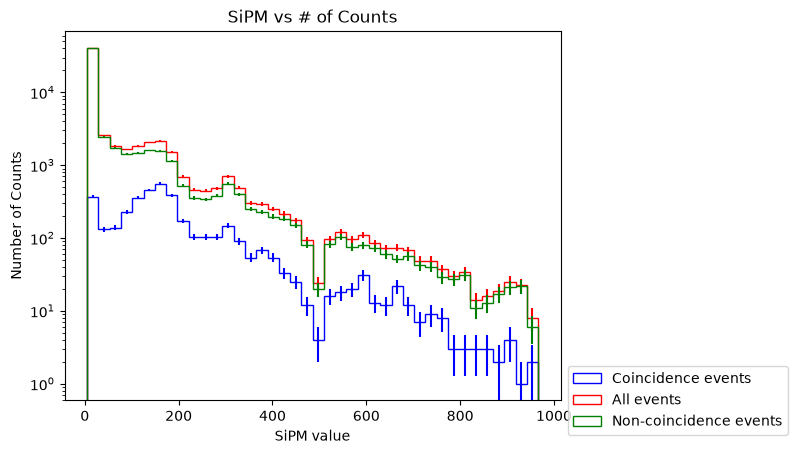

In [21]:
# Histogram shows a coincidence measurement showing the calculated SiPM peak voltage
# Use the format of plt.hist(x, bins=None, range=None, density=False, color=None, edgecolor=None) to plot a histogram of the data.
# Density=False means the y-axis will show the number of counts instead of the density.
# Use histtype="step" to plot a histogram of the data with no fill.

_,sipm_bins,_ = plt.hist(file1.sipm[file1.coincidence==1], bins=40, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(file1.sipm, bins=sipm_bins, histtype="step", range=None, density=False, color="red", label="All events")
plt.hist(file1.sipm[file1.coincidence==0], bins=sipm_bins, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")

# Get the center of the bins and get the number of counts in each bin for all three categories

counts_all, edges = np.histogram(file1.sipm, bins=sipm_bins)
x = 0.5 * (edges[:-1] + edges[1:])  
y = counts_all  

counts_non, edges = np.histogram(file1.sipm[file1.coincidence==0], bins=sipm_bins)
xnon = 0.5 * (edges[:-1] + edges[1:])  
ynon = counts_non

counts_co, edges = np.histogram(file1.sipm[file1.coincidence==1], bins=sipm_bins)
xco = 0.5 * (edges[:-1] + edges[1:])  
yco = counts_co       

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts. 
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')  
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")  
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')  

plt.xlabel("SiPM value")
plt.ylabel("Number of Counts")
plt.title("SiPM vs # of Counts")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.yscale("log")

plt.show()

**Create the SiPM vs # of counts graph seen above with logarithmically spaced bins**

The SiPM pulse amplitude graphs are shown using both linear and log spaced bins. The linear histogram shows the overall distribution and the log histogram uses bins spaced at log intervals, modeling graphs seen in the Cosmic Watch official paper.

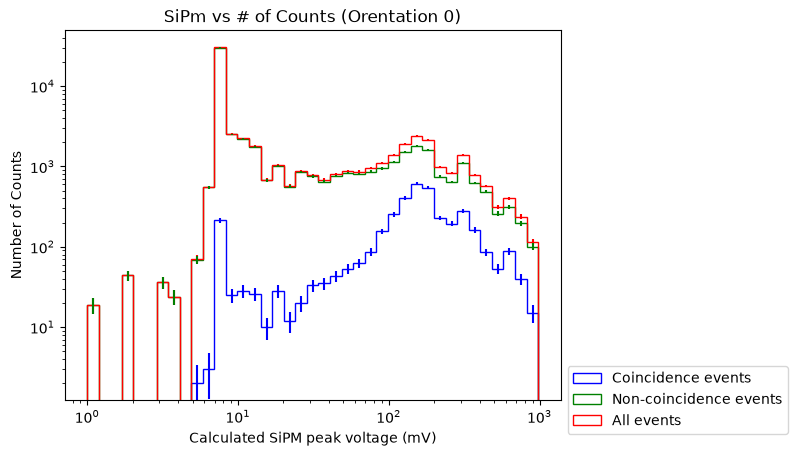

In [22]:
# Create logarithmically spaced bins
bins_sipm = np.logspace(np.log10(file1.sipm.min()), np.log10(file1.sipm.max()), 40)

plt.hist(file1.sipm[file1.coincidence==1], bins=bins_sipm, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(file1.sipm[file1.coincidence==0], bins=bins_sipm, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")
plt.hist(file1.sipm, bins=bins_sipm, histtype="step", range=None, density=False, color="red", label="All events")


# Get the center of the bins and get the number of counts in each bin for all three categories
counts_all, edges = np.histogram(file1.sipm, bins=bins_sipm)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(file1.sipm[file1.coincidence == 0], bins=bins_sipm)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(file1.sipm[file1.coincidence == 1], bins=bins_sipm)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("Number of Counts")
plt.title("SiPm vs # of Counts (Orentation 0)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.xscale("log")
plt.yscale("log")
plt.show()

The blue in the graph above shows that real cosmic ray muons will generally produce a larger SiPM peak voltage.

***
**Coincidence Rate Over Time**

For the graph below, the coincidence rate was calculated in 30-second bins to see how the rate changes over the course of the measurement. The red line shows the overall average coincidence rate.

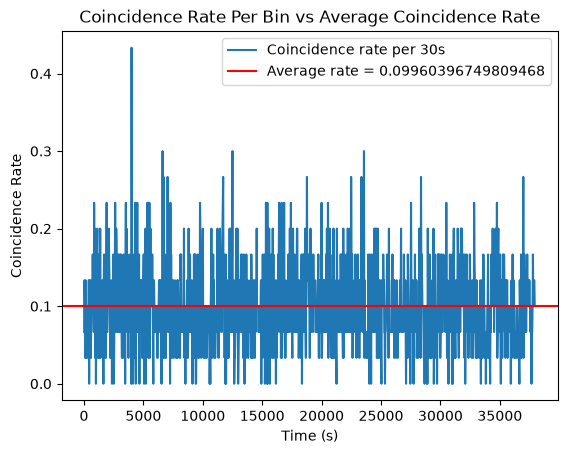

In [23]:
# The graph below compares the coincidence rate during the experiment. The horizontal line represents the average
# coincidence rate and the blue shows the rate per bin. 
bins = 30

# Rate of coincidences per bin (30 seconds)
coincidence_rate_per_bin = file1.binned_coincidence_counts / file1.bin_size

plt.plot(file1.binned_time_s, coincidence_rate_per_bin, label="Coincidence rate per 30s")

plt.axhline(coincidence_rate, color="red", label=f"Average rate = {coincidence_rate}")


plt.xlabel("Time (s)")
plt.ylabel("Coincidence Rate")
plt.title("Coincidence Rate Per Bin vs Average Coincidence Rate")
plt.legend()
plt.show()


***
**Relative Rate Explanation**

Since some detector recordings were done at home and some were done in the lab, each orientation's coincidence rate will be standardized by dividing it by the highest coincidence rate (the reference orientation = O0). This will convert coincidence rates into relative rates, allowing data collected in both locations to be compared.

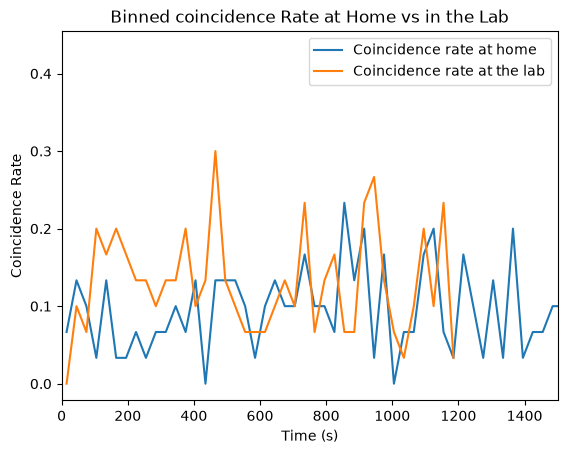

In [24]:
# Below is a graph that compares orentation 0 data recorded at home and in the lab. 
# O0 (the highest rate orientation) will be used to create relative rates.

bins = 30

# Rate of coincidences per bin (30 seconds)
coincidence_rate_per_bin = file1.binned_coincidence_counts / file1.bin_size
coincidence_rate_per_binlab = file1lab.binned_coincidence_counts / file1lab.bin_size

plt.plot(file1.binned_time_s, coincidence_rate_per_bin, label="Coincidence rate at home")
plt.plot(file1lab.binned_time_s, coincidence_rate_per_binlab, label="Coincidence rate at the lab")
plt.xlim(0, 1500)   


plt.xlabel("Time (s)")
plt.ylabel("Coincidence Rate")
plt.title("Binned coincidence Rate at Home vs in the Lab")
plt.legend()
plt.show()

#### Orentation 0 with lead 
Orentation 0 SiPM pulse amplitude measurements were repeated with lead surrounding the detectors to reduce background radiation. This graph with better shpow the muon signal and show if low-amplitude coincidence rate seen in the normal o1 SiPM graph is due to high overall count due to background radiation.

In [34]:
# Repeat code used above for the 01 run with lead (file1lead)

data1lead = pd.read_csv("CW_data1lead.txt", sep=r"\s+", skiprows=5, header=None)
data1lead.columns = [
    "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    "SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel(X:Y:Z)[g]", "Coincidence", 
    "Name1", "Name", "Comp_time", "Comp_date"]
cols_keep = [
    "Comp_date",
    "Comp_time",
    "Event",
    "Ardn_time",
    "ADC_value",
    "SiPM_mV",
    "Deadtime_ms",
    "Temp_C",
    "Name",
    "Coincidence"]
data1lead = data1lead[cols_keep]
data1lead.to_csv("CW_data_101lead.txt", sep=" ", index=False, header=False)

# Load data that was taken from a computer
cwd = os.getcwd()
file1lead = CWClass(cwd + "/CW_data_101lead.txt", bin_size = 30)
coincidence_rate1l = sum(file1lead.coincidence) / file1lead.total_time_s
print(coincidence_rate1l)  

There is an event missing in the data.
Events in file are not sequential.
Count rate: 0.8642 +/- 0.011
0.11908425709855074


/var/folders/ty/03qhdqb1581g649ps7r7812nbr0fy1/T/ipykernel_1866/951693531.py:159: RuntimeWarning: invalid value encountered in divide
  self.binned_coincidence_rate = coincidence / bin_livetime
/var/folders/ty/03qhdqb1581g649ps7r7812nbr0fy1/T/ipykernel_1866/951693531.py:175: RuntimeWarning: invalid value encountered in divide
  self.binned_count_rate = counts/bin_livetime
/var/folders/ty/03qhdqb1581g649ps7r7812nbr0fy1/T/ipykernel_1866/951693531.py:176: RuntimeWarning: invalid value encountered in divide
  self.binned_count_rate_err = np.sqrt(counts)/bin_livetime


**Create the SiPM vs # of counts graph seen above with logarithmically spaced bins**

The SiPM pulse amplitude graphs are shown using both linear and log spaced bins. The linear histogram shows the overall distribution and the log histogram uses bins spaced at log intervals, modeling graphs seen in the Cosmic Watch official paper.

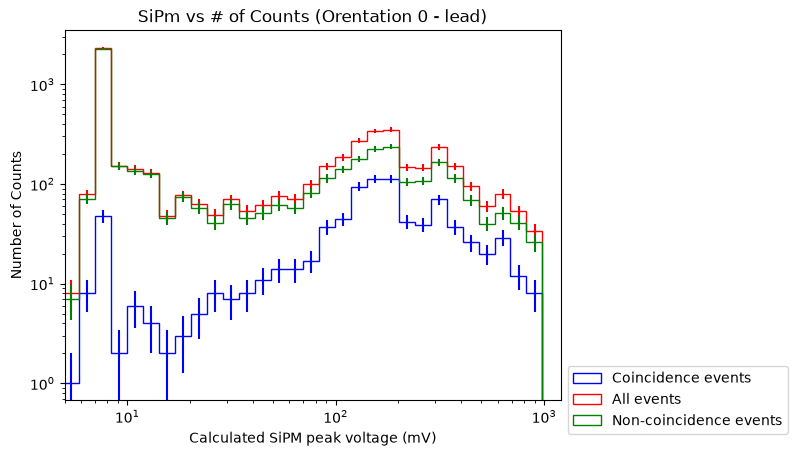

In [35]:
# Create logarithmically spaced bins
bins_sipm = np.logspace(np.log10(file1lead.sipm.min()), np.log10(file1lead.sipm.max()), 40)

plt.hist(file1lead.sipm[file1lead.coincidence==1], bins=bins_sipm, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(file1lead.sipm, bins=bins_sipm, histtype="step", range=None, density=False, color="red", label="All events")
plt.hist(file1lead.sipm[file1lead.coincidence==0], bins=bins_sipm, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")

# Get the center of the bins and get the number of counts in each bin for all three categories
counts_all, edges = np.histogram(file1lead.sipm, bins=bins_sipm)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(file1lead.sipm[file1lead.coincidence == 0], bins=bins_sipm)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(file1lead.sipm[file1lead.coincidence == 1], bins=bins_sipm)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("Number of Counts")
plt.title("SiPm vs # of Counts (Orentation 0 - lead)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.xscale("log")
plt.yscale("log")
plt.xlim(5, 1200)
plt.show()

***

### Section 2: Using lead blocks with CosmicWatch Desktop Muon Detectors to shield background noise.
#### The count decreases beacuse the thickness blocks out background noise while allowing muons to pass through.
#### Loading and cleaning data, establishing coincidence mode and SiPM vs. Time graph.

One measurement included a lead block (8×4×2 inches) between the two detectors and one measurement had a stand in 2 inch block between the detectors to look at how the lead affected the coincidence rate while standarizng the height inbetween.

In [138]:
# Place a 2 inch lead block with the large face covering the block inbetween the detectors
# Record and save file as CW_datalead.txt

# Place a stand in block of 2 inches inbetween the detectors
# Record and save file qs CW_2inch.txt

import pandas as pd

# Load the data file so all 13 columns are present
datalead = pd.read_csv("CW_datalead.txt", sep=r"\s+", skiprows=5, header=None)
data2inch = pd.read_csv("CW_2inch.txt", sep=r"\s+", skiprows=5, header=None)

# Rename the columns: 
    # Assign 2 name columns to data1 because the name of the device registering the data is being split into two columns.

# Use for data1 when using coincidence data:
datalead.columns = [
    "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    "SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel(X:Y:Z)[g]", "Coincidence", 
    "Name1", "Name", "Comp_time", "Comp_date"
]
data2inch.columns = [
    "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    "SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel(X:Y:Z)[g]", "Coincidence", "Name1", "Name", "Comp_time", "Comp_date"
]
cols_keep = [
    "Comp_date",
    "Comp_time",
    "Event",
    "Ardn_time",
    "ADC_value",
    "SiPM_mV",
    "Deadtime_ms",
    "Temp_C",
    "Name",
    "Coincidence"
]   

# Select only the columns we want to keep. Run data2 = data2[cols_keep] if not using coincidence data.

datalead = datalead[cols_keep]
data2inch = data2inch[cols_keep]


# Save cleaned dataset as a 10-column text file with space-separated values 
# so it matches the format required by CWClass (CosmicWatch notebook)
datalead.to_csv("CW_datalead_10col.txt", sep=" ", index=False, header=False)
data2inch.to_csv("CW_data2inch_10col.txt", sep=" ", index=False, header=False)

# Test to check column names and that the constant date column was dropped.
print(datalead.head())



    Comp_date        Comp_time  Event    Ardn_time  ADC_value  SiPM_mV  \
0  24/07/2026  09:33:32.710147     54  0:06:42.164      966.0    243.0   
1  24/07/2026  09:33:32.989771     55  0:06:42.443      458.0      8.0   
2  24/07/2026  09:33:33.482271     56  0:06:42.936      149.0      7.0   
3  24/07/2026  09:33:33.541621     57  0:06:42.995      868.0     81.0   
4  24/07/2026  09:33:35.104636     58  0:06:44.558      219.0      7.0   

   Deadtime_ms  Temp_C         Name  Coincidence  
0        49.50   26.96  Payne-Scott            0  
1        12.54   26.96  Payne-Scott            0  
2         7.98   26.97  Payne-Scott            0  
3        26.53   26.97  Payne-Scott            0  
4         9.69   26.97  Payne-Scott            0  


In [139]:
class CWClass():
    def __init__(self,fname,bin_size = 30):
        self.name = fname.split('/')[-1]
        self.bin_size = bin_size
        
        fileHandle = open(fname,"r" )
        lineList = fileHandle.readlines()
        fileHandle.close()
        header_lines = 0
        
        # Look through the first 1000 lines for the word "Device". Everything prior is considered part of the header.
        for i in range(min(len(lineList),1000)):
            header_in_file = lineList[i]
            if 'Device' in header_in_file:
                header_lines = i+1
  
        #Determine number of columns by looking at the second last line in the file.
        number_of_columns = len(lineList[len(lineList)-2].split(" "))
        column_array = range(0,number_of_columns)

        
        file_from_computer = False
        file_from_sdcard   = False
        
        if number_of_columns == 10:
            file_from_computer = True  # If you have 10 columns, you probably took the data on the computer 
            data = np.genfromtxt(fname, dtype = str, delimiter=' ', usecols=column_array, invalid_raise=False, skip_header=header_lines)
            comp_date = data[:,0] #first column of data
            comp_time = data[:,1]
            event_number = data[:,2].astype(float)
            # The column contained formatted time strings (HH:MM:SS.ms) instead of numeric values.
            # It had to be manually converted to milliseconds for processing.
            Ardn_time_ms = np.array([
                int(t.split(":")[0])*3600 +
                int(t.split(":")[1])*60 +
                float(t.split(":")[2])
                for t in data[:,3]
                ]) * 1000
            adc = data[:,4].astype(float)
            sipm = data[:,5].astype(float)
            deadtime = data[:,6].astype(float)
            temperature = data[:,7].astype(float)
            # Ensure lines say (float) instead of (np.float)
            detName = data[:,8]
            self.coincidence = data[:,9].astype(float) 


            
        elif number_of_columns == 6:
            file_from_sdcard = True # If you have 6 columns, you took the data from the sdCard
            data = np.genfromtxt(fname, dtype = str, delimiter=' ', usecols=column_array, invalid_raise=False, skip_header=header_lines)
            event_number = data[:,0].astype(np.float)
            Ardn_time_ms = data[:,1].astype(np.float)
            adc = data[:,2].astype(np.float)
            sipm = data[:,3].astype(np.float)
            deadtime = data[:,4].astype(np.float)
            temperature = data[:,5].astype(np.float)
            
        else: 
            print('The file format is unknown, or older. If it is an older file format, you will have to change the number of columns in the CW class.')
            
            
        # Simple check to see if the events are sequential
        def sequential(l):
            l = np.asarray(l).astype(int)
            check = range(min(l),max(l)+1)

            if len(l)!=len(check):
                print('There is an event missing in the data.')
                return False

            counter = 0
            for i in range(len(l)):
                counter+=1
                if l[i]!=check[i]:
                    print('Check event number: '+str(counter))
            return sum(check == l)==len(l)

        if not sequential(event_number):
            print('Events in file are not sequential.')

        # Convert the computer time to an absolute time (MJD).
        if file_from_computer:
            time_stamp = []
            for i in range(len(comp_date)):
                comp_date = [d.replace('/', '-') for d in comp_date]
                day  = int(comp_date[i].split('-')[0])
                month = int(comp_date[i].split('-')[1])
                year   = int(comp_date[i].split('-')[2])
                hour  = int(comp_time[i].split(':')[0])
                mins  = int(comp_time[i].split(':')[1])
                sec   = int(np.floor(float(comp_time[i].split(':')[2])))
                try:  
                    decimal = float('0.'+str(comp_time[i].split('.')[-1]))
                except:
                    decimal = 0.0
                time_stamp.append(float(time.mktime((year, month, day, hour, mins, sec, 0, 0, 0)))+ decimal) 


            self.time_stamp_s     = np.asarray(time_stamp) -  min(np.asarray(time_stamp))       # The absolute time of an event in seconds
            self.time_stamp_ms    = np.asarray(time_stamp -  min(np.asarray(time_stamp)))*1000  # The absolute time of an event in miliseconds   
            self.total_time_s     = max(time_stamp) -  min(time_stamp)     # The absolute time of an event in seconds
            self.detector_name    = detName                                
            self.n_detector       = len(set(detName))

        # Convert the cumulative deadtime to the deadtime between events
        # The detector starts at time 0, so append a zero.
        event_deadtime_ms = diff(np.append([0],deadtime))

        # The Arduino absolute time isn't great. Over the course of a few hours, it will be off by several seconds. 
        # The computer will give you accurate time down to about 1ms. Reading from the serial port has ~ms scale uncertainty.
        # The Arduino can give you a precise measurement (down to 1us), but the absolute time will drift. Expect it to be off by roughly 1min per day.
        from datetime import datetime
        

        self.Ardn_time_ms      = Ardn_time_ms
        self.Ardn_time_s       = Ardn_time_ms/1000.
        
        self.Ardn_total_time_s = max(self.Ardn_time_s)
        self.Ardn_total_time_ms= max(self.Ardn_time_s)*1000.

        self.event_number     = np.asarray(event_number)  # an arrray of the event numbers
        self.total_counts     = max(event_number.astype(int)) - min(event_number.astype(int))
        self.adc              = adc         # an arrray of the measured event ADC value
        self.sipm             = sipm        # an arrray of the measured event SiPM value
        
        self.event_deadtime_s   = event_deadtime_ms/1000.      # an array of the measured event deadtime in seconds
        self.event_deadtime_ms  = event_deadtime_ms            # an array of the measured event deadtime in miliseconds
        self.total_deadtime_ms  = max(event_deadtime_ms)       # an array of the measured event deadtime in miliseconds
        self.total_deadtime_s   = max(event_deadtime_ms)/1000. # The total deadtime in seconds
                
        # The time between events is well described by the Arduino timestamp. 
        # The 'diff' command takes the difference between each element in the array.
        self.Ardn_event_livetime_s = diff(np.append([0],self.Ardn_time_s)) - self.event_deadtime_s
        

 
        if file_from_computer:
            self.live_time        = (self.total_time_s - self.total_deadtime_s)
            self.weights          = np.ones(len(event_number)) / self.live_time
            self.count_rate       = self.total_counts/self.live_time 
            self.count_rate_err   = np.sqrt(self.total_counts)/self.live_time 

            bins = range(0,int(max(self.time_stamp_s)), self.bin_size)
            counts, binEdges       = np.histogram(self.time_stamp_s, bins = bins)
            coincidence, binEdges  = np.histogram(self.time_stamp_s[self.coincidence == 1], bins = bins)
            bin_livetime, binEdges = np.histogram(self.time_stamp_s, bins = bins, weights = self.Ardn_event_livetime_s)

            self.binned_coincidence_counts = coincidence
            self.binned_coincidence_rate = coincidence / bin_livetime
    
    
        elif file_from_sdcard:
            self.live_time        = (self.Ardn_total_time_ms - self.total_deadtime_ms)/1000.
            self.weights          = np.ones(len(event_number)) / self.live_time
            self.count_rate       = self.total_counts/self.live_time 
            self.count_rate_err   = np.sqrt(self.total_counts)/self.live_time 

            bins = range(int(min(self.Ardn_time_s)),int(max(self.Ardn_time_s)),self.bin_size)
            counts, binEdges = np.histogram(self.Ardn_time_s, bins = bins)
            bin_livetime, binEdges = np.histogram(self.Ardn_time_s, bins = bins, weights = self.Ardn_event_livetime_s)
            
        else:
            print('Error')
        
        print('Count rate: '+str(np.round(self.count_rate,4)) +' +/- '+ str(np.round(self.count_rate_err,4)))
        
        bincenters = 0.5*(binEdges[1:]+ binEdges[:-1])
        
        self.bin_size          = bin_size
        self.binned_counts     = counts
        self.binned_counts_err = np.sqrt(counts)
        self.binned_count_rate = counts/bin_livetime
        self.binned_count_rate_err = np.sqrt(counts)/bin_livetime
        self.binned_time_s     = bincenters
        self.binned_time_m     = bincenters/60.

    
        
def plusSTD(n,array):
    xh = np.add(n,np.sqrt(np.abs(array)))
    return xh

def subSTD(n,array):
    xl = np.subtract(n,np.sqrt(np.abs(array)))
    return xl

def fill_between_steps(x, y1, y2=0, h_align='mid', ax=None,lw=2, **kwargs):
    # If no Axes opject given, grab the current one:
    if ax is None:
        ax = plt.gca()
    # First, duplicate the x values
    xx = x.repeat(2)[1:]
    # Now: the average x binwidth
    xstep = sp.repeat((x[1:] - x[:-1]), 2)
    xstep = sp.concatenate(([xstep[0]], xstep, [xstep[-1]]))
    # Now: add one step at end of row.
    xx = sp.append(xx, xx.max() + xstep[-1])

    # Make it possible to chenge step alignment.
    if h_align == 'mid':
        xx -= xstep / 2.
    elif h_align == 'right':
        xx -= xstep

    # Also, duplicate each y coordinate in both arrays
    y1 = y1.repeat(2)#[:-1]
    if type(y2) == sp.ndarray:
        y2 = y2.repeat(2)#[:-1]

    # now to the plotting part:
    ax.fill_between(xx, y1, y2=y2,lw=lw, **kwargs)
    return ax

print('Definitions complete ...')

Definitions complete ...


In [140]:
# Load data that was taken from a computer
cwd = os.getcwd()

# Make sure you use the 10-column text file that was created from the original data file. 
filelead = CWClass(cwd + "/CW_datalead_10col.txt", bin_size = 30)

leadcoincidence_rate = sum(filelead.coincidence) / filelead.total_time_s
# Count how many ones are in the coincidence column (sum) and divide by the total time in seconds to get the coincidence rate in Hz.
print(leadcoincidence_rate)  

# Make sure you use the 10-column text file that was created from the original data file. 
file2inch = CWClass(cwd + "/CW_data2inch_10col.txt", bin_size = 30)

inchcoincidence_rate = sum(file2inch.coincidence) / file2inch.live_time
print(inchcoincidence_rate)  


Count rate: 1.2316 +/- 0.0115
0.0405562011804351
Count rate: 1.478 +/- 0.0061
0.03230604429965078


In [142]:
# Divide each orientation’s rate by the rate of the reference (the highest-rate orientation))
# This will convert coincidence rates into relative rates, allowing data collected in both locations to be compared.
print("Lead rate:", leadcoincidence_rate)

# Lead run was done in the lab
leadrelative_rate = leadcoincidence_rate/coincidence_ratelab
print("Lead relative rate:", leadrelative_rate)

print("2 inch block rate:", inchcoincidence_rate)

# The run with the two inch stand in block was done athome
inchrelative_rate = inchcoincidence_rate/coincidence_rate
print("2 inch block relative rate:", inchrelative_rate)

Lead rate: 0.0405562011804351
Lead relative rate: 0.3191583271944385
2 inch block rate: 0.03230604429965078
2 inch block relative rate: 0.3243449544343579


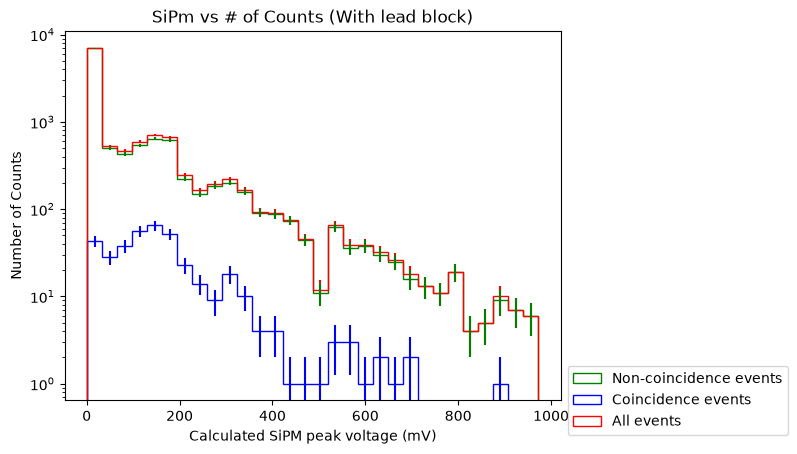

In [143]:
_,bins,_ = plt.hist(filelead.sipm[filelead.coincidence==0], bins=30, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")
plt.hist(filelead.sipm[filelead.coincidence==1], bins=bins, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(filelead.sipm, bins=bins, histtype="step", range=None, density=False, color="red", label="All events")


# Get the center of the bins and get the number of counts in each bin for all three categories

counts_all, edges = np.histogram(filelead.sipm, bins=bins)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(filelead.sipm[filelead.coincidence == 0], bins=bins)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(filelead.sipm[filelead.coincidence == 1], bins=bins)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("Number of Counts")
plt.title("SiPm vs # of Counts (With lead block)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.yscale("log")

plt.show()

**Create the SiPM vs # of counts graph seen above with logarithmically spaced bins**

The SiPM pulse amplitude graphs are shown using both linear and log spaced bins. The linear histogram shows the overall distribution and the log histogram uses bins spaced at log intervals, modeling graphs seen in the Cosmic Watch official paper.

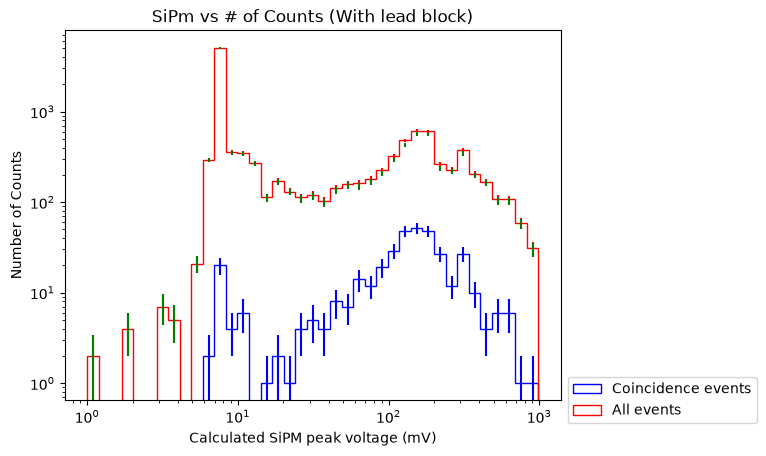

In [144]:
# Create logarithmically spaced bins
bins_sipm = np.logspace(np.log10(filelead.sipm.min()), np.log10(filelead.sipm.max()), 40)
plt.hist(filelead.sipm[filelead.coincidence==1], bins=bins_sipm, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(filelead.sipm, bins=bins_sipm, histtype="step", range=None, density=False, color="red", label="All events")


# Get the center of the bins and get the number of counts in each bin for all three categories

counts_all, edges = np.histogram(filelead.sipm, bins=bins_sipm)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(filelead.sipm[filelead.coincidence == 0], bins=bins_sipm)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(filelead.sipm[filelead.coincidence == 1], bins=bins_sipm)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("Number of Counts")
plt.title("SiPm vs # of Counts (With lead block)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.yscale("log")
plt.xscale("log")

plt.show()

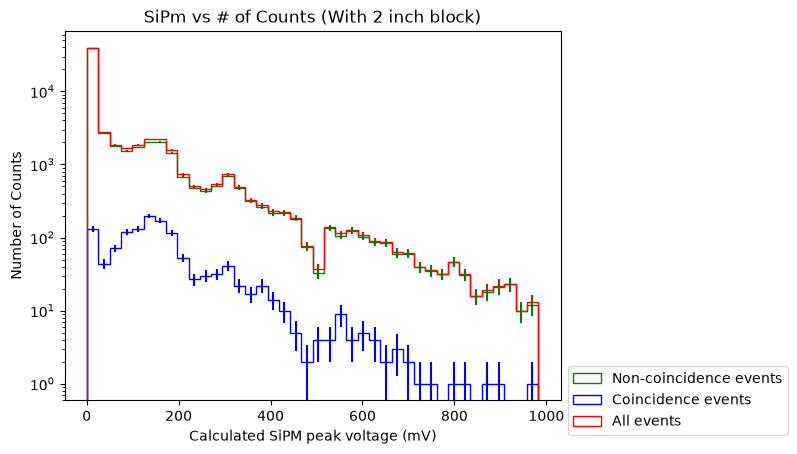

In [145]:
_,bins,_ = plt.hist(file2inch.sipm[file2inch.coincidence==0], bins=40, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")
plt.hist(file2inch.sipm[file2inch.coincidence==1], bins=bins, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(file2inch.sipm, bins=bins, histtype="step", range=None, density=False, color="red", label="All events")


# Get the center of the bins and get the number of counts in each bin for all three categories

counts_all, edges = np.histogram(file2inch.sipm, bins=bins)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(file2inch.sipm[file2inch.coincidence == 0], bins=bins)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(file2inch.sipm[file2inch.coincidence == 1], bins=bins)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("Number of Counts")
plt.title("SiPm vs # of Counts (With 2 inch block)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.yscale("log")

plt.show()

**Create the SiPM vs # of counts graph seen above with logarithmically spaced bins**

The SiPM pulse amplitude graphs are shown using both linear and log spaced bins. The linear histogram shows the overall distribution and the log histogram uses bins spaced at log intervals, modeling graphs seen in the Cosmic Watch official paper.

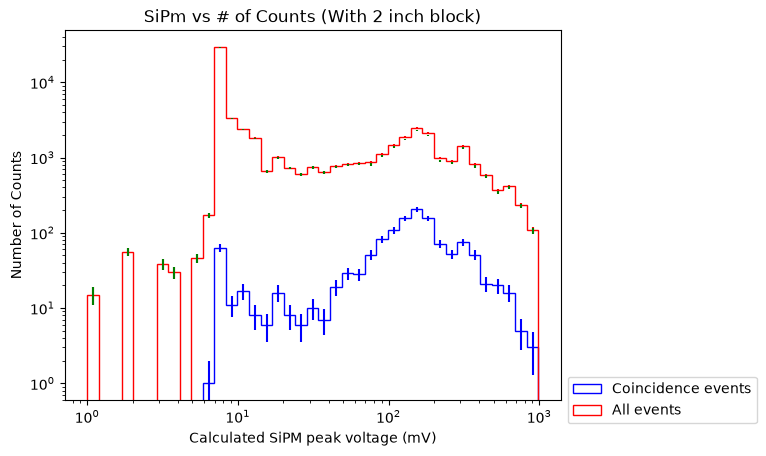

In [146]:
# Create logarithmically spaced bins
bins_sipm = np.logspace(np.log10(file2inch.sipm.min()), np.log10(file2inch.sipm.max()), 40)
plt.hist(file2inch.sipm[file2inch.coincidence==1], bins=bins_sipm, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(file2inch.sipm, bins=bins_sipm, histtype="step", range=None, density=False, color="red", label="All events")


# Get the center of the bins and get the number of counts in each bin for all three categories

counts_all, edges = np.histogram(file2inch.sipm, bins=bins_sipm)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(file2inch.sipm[file2inch.coincidence == 0], bins=bins_sipm)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(file2inch.sipm[file2inch.coincidence == 1], bins=bins_sipm)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("Number of Counts")
plt.title("SiPm vs # of Counts (With 2 inch block)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.yscale("log")
plt.xscale("log")

plt.show()

The graphs below wil show if the coincidence rate is considence over the course of the run for both the 2 inch block and lead block datasets.

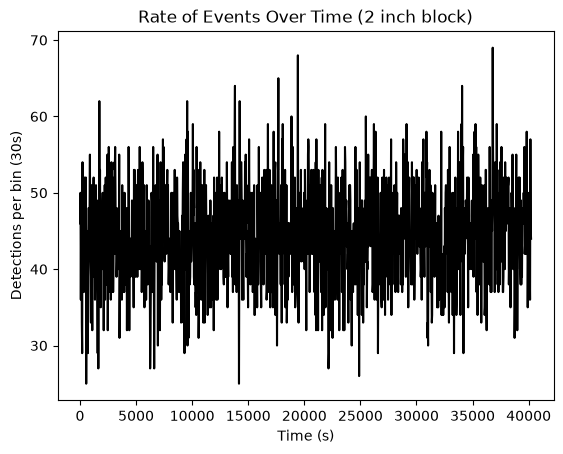

In [147]:
# Check to see that the rate for each orentation is consistent during the 2 inch block run.

plt.plot(file2inch.binned_time_s, file2inch.binned_counts, color="black")
# Binned counts are the number of events that occurred in each time bin (30 seconds in this case).

plt.xlabel("Time (s)")
plt.ylabel("Detections per bin (30s)")
plt.title("Rate of Events Over Time (2 inch block)")
plt.show()

# If you see a big drop, there are errors with data collection. Must rerun.

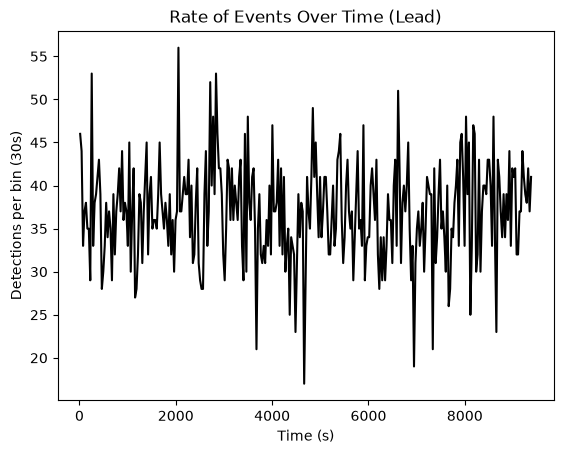

In [148]:
# Check to see that the rate for each orentation is consistent during the lead run.

plt.plot(filelead.binned_time_s, filelead.binned_counts, color="black")
# Binned counts are the number of events that occurred in each time bin (30 seconds in this case).

plt.xlabel("Time (s)")
plt.ylabel("Detections per bin (30s)")
plt.title("Rate of Events Over Time (Lead)")
plt.show()

# If you see a big drop, there are errors with data collection. Must rerun.

****
Comparison of Coincidence Rates With and Without Lead

This graph compares the relative muon coincidence rate with no lead block and with lead block between the detectors with poisson uncertainty.

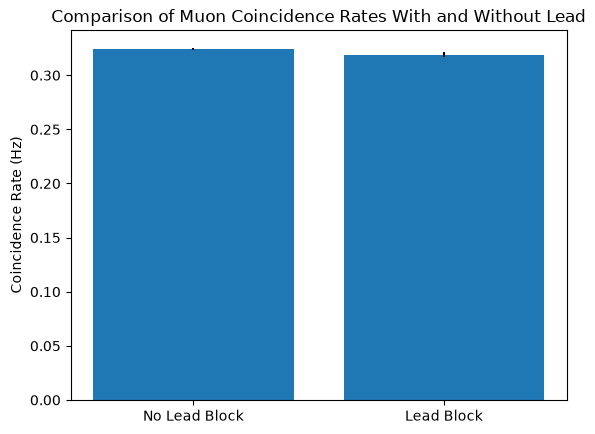

In [149]:
labels = ["No Lead Block", "Lead Block"]
rates = [inchrelative_rate, leadrelative_rate]


lead_counts = np.sum(filelead.coincidence)
inch_counts = np.sum(file2inch.coincidence)

poisson_error_lead = np.sqrt(lead_counts)/filelead.total_time_s
poisson_error_none = np.sqrt(inch_counts)/file2inch.total_time_s
# Can't use sqrt(counts) because this graph shows rates, not counts.
# Divide by the total measurement to convert units.

errors = [poisson_error_none, poisson_error_lead]
plt.bar(labels, rates, yerr=errors)

plt.ylabel("Coincidence Rate (Hz)")
plt.title("Comparison of Muon Coincidence Rates With and Without Lead")
plt.show()

****
After reading "Using Cosmic Watch Detectors to Measure the Attenuation Coefficient of Cosmic Muon in the Lead Bricks" (DOI:10.1088/1742-6596/2386/1/012073), I apppied that to the detector setup. The paper shows the decrease in the coincidence rate once lead is used using this equation:

R=R0e^−μL (R0 is the coincidence rate without lead, R is the coincidence rate with lead, L is the lead thickness, and μ is the attenuation coefficient)

I compared to the lead recording coinicidence rate to the coincidence rate measured with the stand in block of the same height. With this, I was able to calculate μ from the equation given. The work is included below to show a initial test.

In [ ]:
R = leadrelative_rate
R0 = inchrelative_rate # coincidence_rate without lead block but still 2 inches up
L = 5.08  # 2 inches = 5.08 cm
# Having L in centimeters makes mu in cm^-1

# Equation sourced from DOI:10.1088/1742-6596/2386/1/012073:
# "Using Cosmic Watch Detectors to Measure the Attenuation 
# Coefficient of Cosmic Muon in the Lead Bricks" 
# where the calulated value was 0.01983 (cm^-1)

mu = -np.log(R / R0) / L

print("Attenuation coefficient:", mu)


Attenuation coefficient: 0.011331180853624865


***

### Section 3: CW_datao1.txt (Orentation 1 in coincidence mode)
#### Loading and cleaning data, establishing coincidence mode and SiPM vs. Time graph.
Orentation 1 is when the detectors are placed on top of eachother with the face facing sideways.

In [ ]:
# As the solid angle between detectors increases and therefore the coincidence rate as well.
# This orentation will produce the second smallest solid angle. 
#CW_datao1.txt is a data file that was taken with orentation 1.

import pandas as pd

# Load the data file so all 13 columns are present
datao1 = pd.read_csv("CW_datao1.txt", sep=r"\s+", skiprows=5, header=None)

# Rename the columns: 
    # Assign 1 or 2 name columns to data based the name of the device. Use 2 if if the name is being split into two columns.

# Use for data1 when using coincidence data:
datao1.columns = [
    "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    "SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel(X:Y:Z)[g]", "Coincidence", "Name1",
      "Name", "Comp_time", "Comp_date"
]
# Select only the columns we want to keep. Run data2 = data2[cols_keep] if not using coincidence data.

cols_keep = [
    "Comp_date",
    "Comp_time",
    "Event",
    "Ardn_time",
    "ADC_value",
    "SiPM_mV",
    "Deadtime_ms",
    "Temp_C",
    "Name",
    "Coincidence"
]
datao1 = datao1[cols_keep]


# Save cleaned dataset as a 10-column text file with space-separated values 
# so it matches the format required by CWClass (CosmicWatch notebook)
datao1.to_csv("CW_datao1_10col.txt", sep=" ", index=False, header=False)

# Test to check column names and that the constant date column was dropped.
print(datao1.head())


    Comp_date        Comp_time  Event    Ardn_time  ADC_value  SiPM_mV  \
0  20/07/2026  21:44:08.931194     69  0:01:54.487      783.0     28.0   
1  20/07/2026  21:44:09.359893     70  0:01:54.917      130.0      8.0   
2  20/07/2026  21:44:09.489445     71  0:01:55.047      105.0      8.0   
3  20/07/2026  21:44:10.091680     72  0:01:55.649       94.0      8.0   
4  20/07/2026  21:44:11.512482     73  0:01:57.070      333.0      8.0   

   Deadtime_ms  Temp_C         Name  Coincidence  
0        19.88   23.06  Payne-Scott            0  
1         7.44   23.06  Payne-Scott            0  
2         6.73   23.06  Payne-Scott            0  
3         6.44   23.06  Payne-Scott            0  
4        11.47   23.07  Payne-Scott            0  


In [ ]:
class CWClass():
    def __init__(self,fname,bin_size = 30):
        self.name = fname.split('/')[-1]
        self.bin_size = bin_size
        
        fileHandle = open(fname,"r" )
        lineList = fileHandle.readlines()
        fileHandle.close()
        header_lines = 0
        
        # Look through the first 1000 lines for the word "Device". Everything prior is considered part of the header.
        for i in range(min(len(lineList),1000)):
            header_in_file = lineList[i]
            if 'Device' in header_in_file:
                header_lines = i+1
  
        #Determine number of columns by looking at the second last line in the file.
        number_of_columns = len(lineList[len(lineList)-2].split(" "))
        column_array = range(0,number_of_columns)

        
        file_from_computer = False
        file_from_sdcard   = False
        
        if number_of_columns == 10:
            file_from_computer = True  # If you have 10 columns, you probably took the data on the computer 
            data = np.genfromtxt(fname, dtype = str, delimiter=' ', usecols=column_array, invalid_raise=False, skip_header=header_lines)
            comp_date = data[:,0] #first column of data
            comp_time = data[:,1]
            event_number = data[:,2].astype(float)
            # The column contained formatted time strings (HH:MM:SS.ms) instead of numeric values.
            # It had to be manually converted to milliseconds for processing.
            Ardn_time_ms = np.array([
                int(t.split(":")[0])*3600 +
                int(t.split(":")[1])*60 +
                float(t.split(":")[2])
                for t in data[:,3]
                ]) * 1000
            adc = data[:,4].astype(float)
            sipm = data[:,5].astype(float)
            deadtime = data[:,6].astype(float)
            temperature = data[:,7].astype(float)
            # Ensure lines say (float) instead of (np.float)
            detName = data[:,8]
            self.coincidence = data[:,9].astype(float) 


            
        elif number_of_columns == 6:
            file_from_sdcard = True # If you have 6 columns, you took the data from the sdCard
            data = np.genfromtxt(fname, dtype = str, delimiter=' ', usecols=column_array, invalid_raise=False, skip_header=header_lines)
            event_number = data[:,0].astype(np.float)
            Ardn_time_ms = data[:,1].astype(np.float)
            adc = data[:,2].astype(np.float)
            sipm = data[:,3].astype(np.float)
            deadtime = data[:,4].astype(np.float)
            temperature = data[:,5].astype(np.float)
            
        else: 
            print('The file format is unknown, or older. If it is an older file format, you will have to change the number of columns in the CW class.')
            
            
        # Simple check to see if the events are sequential
        def sequential(l):
            l = np.asarray(l).astype(int)
            check = range(min(l),max(l)+1)

            if len(l)!=len(check):
                print('There is an event missing in the data.')
                return False

            counter = 0
            for i in range(len(l)):
                counter+=1
                if l[i]!=check[i]:
                    print('Check event number: '+str(counter))
            return sum(check == l)==len(l)

        if not sequential(event_number):
            print('Events in file are not sequential.')

        # Convert the computer time to an absolute time (MJD).
        if file_from_computer:
            time_stamp = []
            for i in range(len(comp_date)):
                comp_date = [d.replace('/', '-') for d in comp_date]
                day  = int(comp_date[i].split('-')[0])
                month = int(comp_date[i].split('-')[1])
                year   = int(comp_date[i].split('-')[2])
                hour  = int(comp_time[i].split(':')[0])
                mins  = int(comp_time[i].split(':')[1])
                sec   = int(np.floor(float(comp_time[i].split(':')[2])))
                try:  
                    decimal = float('0.'+str(comp_time[i].split('.')[-1]))
                except:
                    decimal = 0.0
                time_stamp.append(float(time.mktime((year, month, day, hour, mins, sec, 0, 0, 0)))+ decimal) 


            self.time_stamp_s     = np.asarray(time_stamp) -  min(np.asarray(time_stamp))       # The absolute time of an event in seconds
            self.time_stamp_ms    = np.asarray(time_stamp -  min(np.asarray(time_stamp)))*1000  # The absolute time of an event in miliseconds   
            self.total_time_s     = max(time_stamp) -  min(time_stamp)     # The absolute time of an event in seconds
            self.detector_name    = detName                                
            self.n_detector       = len(set(detName))

        # Convert the cumulative deadtime to the deadtime between events
        # The detector starts at time 0, so append a zero.
        event_deadtime_ms = diff(np.append([0],deadtime))

        # The Arduino absolute time isn't great. Over the course of a few hours, it will be off by several seconds. 
        # The computer will give you accurate time down to about 1ms. Reading from the serial port has ~ms scale uncertainty.
        # The Arduino can give you a precise measurement (down to 1us), but the absolute time will drift. Expect it to be off by roughly 1min per day.
        from datetime import datetime
        

        self.Ardn_time_ms      = Ardn_time_ms
        self.Ardn_time_s       = Ardn_time_ms/1000.
        
        self.Ardn_total_time_s = max(self.Ardn_time_s)
        self.Ardn_total_time_ms= max(self.Ardn_time_s)*1000.

        self.event_number     = np.asarray(event_number)  # an arrray of the event numbers
        self.total_counts     = max(event_number.astype(int)) - min(event_number.astype(int))
        self.adc              = adc         # an arrray of the measured event ADC value
        self.sipm             = sipm        # an arrray of the measured event SiPM value
        
        self.event_deadtime_s   = event_deadtime_ms/1000.      # an array of the measured event deadtime in seconds
        self.event_deadtime_ms  = event_deadtime_ms            # an array of the measured event deadtime in miliseconds
        self.total_deadtime_ms  = max(event_deadtime_ms)       # an array of the measured event deadtime in miliseconds
        self.total_deadtime_s   = max(event_deadtime_ms)/1000. # The total deadtime in seconds
                
        # The time between events is well described by the Arduino timestamp. 
        # The 'diff' command takes the difference between each element in the array.
        self.Ardn_event_livetime_s = diff(np.append([0],self.Ardn_time_s)) - self.event_deadtime_s
        


        if file_from_computer:
            self.live_time        = (self.total_time_s - self.total_deadtime_s)
            self.weights          = np.ones(len(event_number)) / self.live_time
            self.count_rate       = self.total_counts/self.live_time 
            self.count_rate_err   = np.sqrt(self.total_counts)/self.live_time 

            bins = range(0,int(max(self.time_stamp_s)), self.bin_size)
            counts, binEdges       = np.histogram(self.time_stamp_s, bins = bins)
            coincidence, binEdges  = np.histogram(self.time_stamp_s[self.coincidence == 1], bins = bins)
            bin_livetime, binEdges = np.histogram(self.time_stamp_s, bins = bins, weights = self.Ardn_event_livetime_s)

            self.binned_coincidence_counts = coincidence
            self.binned_coincidence_rate = coincidence / bin_livetime
    
        
        elif file_from_sdcard:
            self.live_time        = (self.Ardn_total_time_ms - self.total_deadtime_ms)/1000.
            self.weights          = np.ones(len(event_number)) / self.live_time
            self.count_rate       = self.total_counts/self.live_time 
            self.count_rate_err   = np.sqrt(self.total_counts)/self.live_time 

            bins = range(int(min(self.Ardn_time_s)),int(max(self.Ardn_time_s)),self.bin_size)
            counts, binEdges = np.histogram(self.Ardn_time_s, bins = bins)
            bin_livetime, binEdges = np.histogram(self.Ardn_time_s, bins = bins, weights = self.Ardn_event_livetime_s)
            
        else:
            print('Error')
        
        print('Count rate: '+str(np.round(self.count_rate,4)) +' +/- '+ str(np.round(self.count_rate_err,4)))
        
        bincenters = 0.5*(binEdges[1:]+ binEdges[:-1])
        
        self.bin_size          = bin_size
        self.binned_counts     = counts
        self.binned_counts_err = np.sqrt(counts)
        self.binned_count_rate = counts/bin_livetime
        self.binned_count_rate_err = np.sqrt(counts)/bin_livetime
        self.binned_time_s     = bincenters
        self.binned_time_m     = bincenters/60.

    
        
def plusSTD(n,array):
    xh = np.add(n,np.sqrt(np.abs(array)))
    return xh

def subSTD(n,array):
    xl = np.subtract(n,np.sqrt(np.abs(array)))
    return xl

def fill_between_steps(x, y1, y2=0, h_align='mid', ax=None,lw=2, **kwargs):
    # If no Axes opject given, grab the current one:
    if ax is None:
        ax = plt.gca()
    # First, duplicate the x values
    xx = x.repeat(2)[1:]
    # Now: the average x binwidth
    xstep = sp.repeat((x[1:] - x[:-1]), 2)
    xstep = sp.concatenate(([xstep[0]], xstep, [xstep[-1]]))
    # Now: add one step at end of row.
    xx = sp.append(xx, xx.max() + xstep[-1])

    # Make it possible to chenge step alignment.
    if h_align == 'mid':
        xx -= xstep / 2.
    elif h_align == 'right':
        xx -= xstep

    # Also, duplicate each y coordinate in both arrays
    y1 = y1.repeat(2)#[:-1]
    if type(y2) == sp.ndarray:
        y2 = y2.repeat(2)#[:-1]

    # now to the plotting part:
    ax.fill_between(xx, y1, y2=y2,lw=lw, **kwargs)
    return ax

print('Definitions complete ...')

Definitions complete ...


In [48]:
# Load data that was taken from a computer
cwd = os.getcwd()

# Make sure you use the 10-column text file that was created from the original data file. 
fileo1 = CWClass(cwd + "/CW_datao1_10col.txt", bin_size = 30)

o1coincidence_rate = sum(fileo1.coincidence) / fileo1.total_time_s
# Count how many ones are in the coincidence column (sum) and divide by the total time in seconds to get the coincidence rate in Hz.
print(o1coincidence_rate)  

Count rate: 1.4959 +/- 0.0062
0.013231515828391058


In [49]:
# Divide each orientation’s rate by the rate of the reference (the highest-rate orientation)
# This will convert the coincidence rates into a relative rates, allowing data collected across locations to be compared.
print("Orientation 1 rate:", o1coincidence_rate)

# Divide all home measurements by the home reference rate
# Orentation 1 was done at home
o1relativerate=(o1coincidence_rate/coincidence_rate)
print("Orientation 1 relative rate:", o1relativerate)

Orientation 1 rate: 0.013231515828391058
Orientation 1 relative rate: 0.13284125282102005


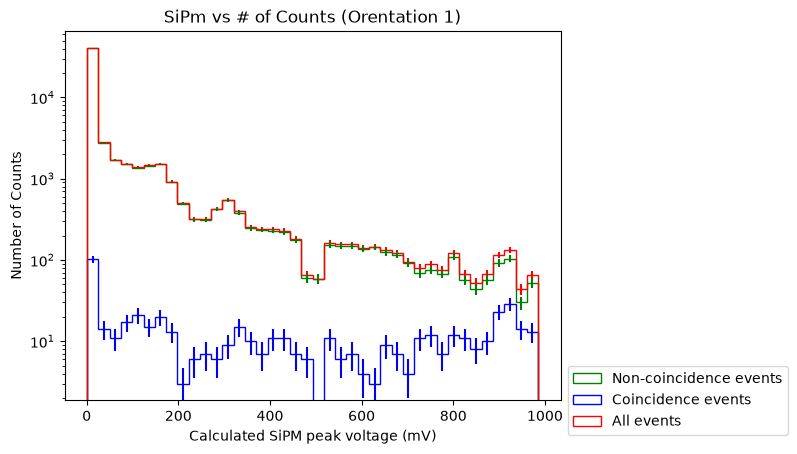

In [50]:
# Histogram shows a coincidence measurement showing the calculated SiPM peak voltage
# Use the format of plt.hist(x, bins=None, range=None, density=False, color=None, edgecolor=None) to plot a histogram of the data.
# Use histtype="step" to plot a histogram of the data with no fill.
_,bins_sipm,_ = plt.hist(fileo1.sipm[fileo1.coincidence==0], bins=40, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")
plt.hist(fileo1.sipm[fileo1.coincidence==1], bins=bins_sipm, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(fileo1.sipm, bins=bins_sipm, histtype="step", range=None, density=False, color="red", label="All events")

#edit the log space bins

# Get the center of the bins and get the number of counts in each bin for all three categories

counts_all, edges = np.histogram(fileo1.sipm, bins=bins_sipm)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(fileo1.sipm[fileo1.coincidence == 0], bins=bins_sipm)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(fileo1.sipm[fileo1.coincidence == 1], bins=bins_sipm)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("Number of Counts")
plt.title("SiPm vs # of Counts (Orentation 1)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.yscale("log")

plt.show()

**Create the SiPM vs # of counts graph seen above with logarithmically spaced bins**

The SiPM pulse amplitude graphs are shown using both linear and log spaced bins. The linear histogram shows the overall distribution and the log histogram uses bins spaced at log intervals, modeling graphs seen in the Cosmic Watch official paper.

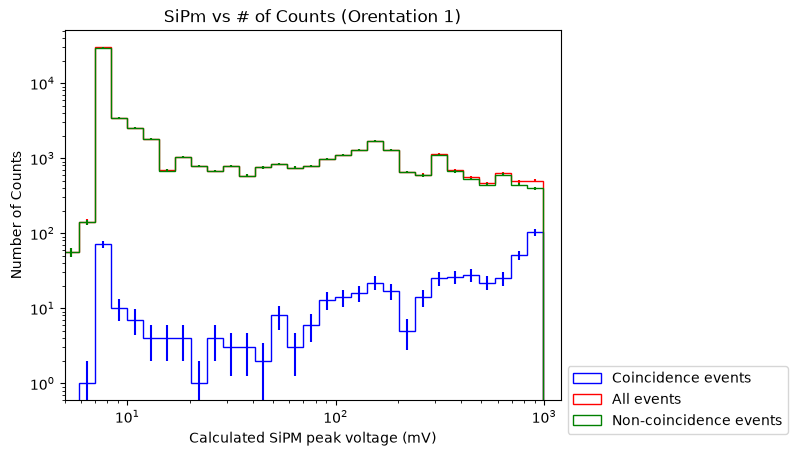

In [ ]:
# Create logarithmically spaced bins
bins_sipm = np.logspace(np.log10(fileo1.sipm.min()), np.log10(fileo1.sipm.max()), 40)

plt.hist(fileo1.sipm[fileo1.coincidence==1], bins=bins_sipm, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(fileo1.sipm, bins=bins_sipm, histtype="step", range=None, density=False, color="red", label="All events")
plt.hist(fileo1.sipm[fileo1.coincidence==0], bins=bins_sipm, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")

# Get the center of the bins and get the number of counts in each bin for all three categories
counts_all, edges = np.histogram(fileo1.sipm, bins=bins_sipm)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(fileo1.sipm[fileo1.coincidence == 0], bins=bins_sipm)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(fileo1.sipm[fileo1.coincidence == 1], bins=bins_sipm)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("Number of Counts")
plt.title("SiPm vs # of Counts (Orentation 1)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.xscale("log")
plt.yscale("log")
plt.xlim(5, 1200)
plt.show()

***
**Coincidence Rate Over Time**

For the graph below, the coincidence rate was calculated in 30-second bins to see how the rate changes over the course of the measurement. The red line shows the overall average coincidence rate.

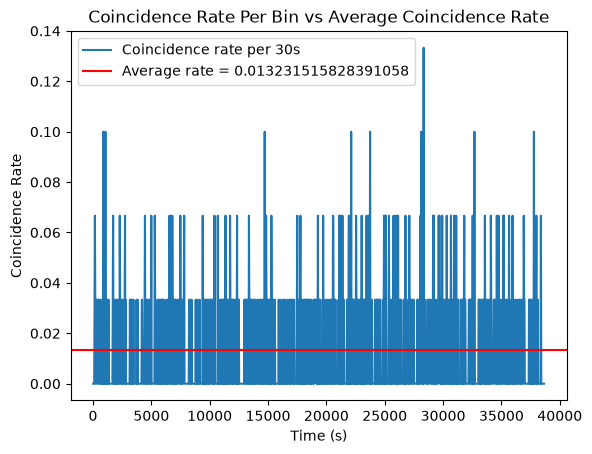

In [ ]:
bin_size = 30

# Rate of coincidences per bin (30 seconds)
coincidence_rate_per_bin = fileo1.binned_coincidence_counts / fileo1.bin_size

plt.plot(fileo1.binned_time_s, coincidence_rate_per_bin, label="Coincidence rate per 30s")

plt.axhline(o1coincidence_rate, color="red", label=f"Average rate = {o1coincidence_rate}")

plt.xlabel("Time (s)")
plt.ylabel("Coincidence Rate")
plt.title("Coincidence Rate Per Bin vs Average Coincidence Rate")
plt.legend()
plt.show()

# This plot shows the coincidence rate calculated in 30-second bins.
# The red line shows the overall average coincidence rate.

Coincidence Rate Variation Throughout the Run

The graph below shows the coincidence rate throughout the run in 40 intervals. The red line shows the overall average coincidence rate.

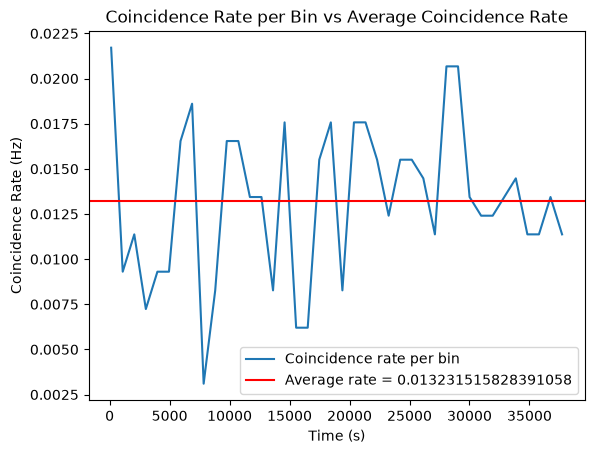

In [ ]:
# Get times of coincidence events
coincidence_times = fileo1.time_stamp_s[fileo1.coincidence == 1]

# Split the full run into 40 equal groups
coincidence_counts, edges = np.histogram(coincidence_times, bins=40)

bin_width = fileo1.total_time_s / 40

# Convert counts to rate (Hz)
coincidence_rate_per_bin = coincidence_counts / bin_width # Rate in each of the 40 total bins

time = (edges[:-1])

plt.plot(time, coincidence_rate_per_bin, label="Coincidence rate per bin")
plt.axhline(o1coincidence_rate, color="red", label=f"Average rate = {o1coincidence_rate}")

plt.xlabel("Time (s)")
plt.ylabel("Coincidence Rate (Hz)")
plt.title("Coincidence Rate per Bin vs Average Coincidence Rate")
plt.legend()
plt.show()

***

### Section 4: CW_datao2.txt (Orentation 2 in coincidence mode)
#### Loading and cleaning data, establishing coincidence mode and SiPM vs. Time graph.
Orentation 2 is when the detectors are placed with a 3.75 inch block inbetween the faces facing sideways.

In [52]:
# As the solid angle between detectors increases and therefore the coincidence rate as well.
# This orentation will produce the smallest solid angle. 
#CW_datao2.txt is a data file that was taken with orentation 2.

import pandas as pd

# Load the data file so all 13 columns are present
datao2 = pd.read_csv("CW_datao2.txt", sep=r"\s+", skiprows=5, header=None)

# Rename the columns: 
    # Assign 1 or 2 name columns to data based the name of the device. Use 2 if if the name is being split into two columns.

# Use for data1 when using coincidence data:
datao2.columns = [
    "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    "SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel(X:Y:Z)[g]", "Coincidence", 
      "Name", "Comp_time", "Comp_date"
]

cols_keep = [
    "Comp_date",
    "Comp_time",
    "Event",
    "Ardn_time",
    "ADC_value",
    "SiPM_mV",
    "Deadtime_ms",
    "Temp_C",
    "Name",
    "Coincidence"
]

datao2 = datao2[cols_keep]

# Save cleaned dataset as a 10-column text file with space-separated values 
# so it matches the format required by CWClass (CosmicWatch notebook)
datao2.to_csv("CW_datao2_10col.txt", sep=" ", index=False, header=False)

# Test to check column names and that the constant date column was dropped.
print(datao2.head())


    Comp_date        Comp_time  Event    Ardn_time  ADC_value  SiPM_mV  \
0  09/07/2026  14:03:41.088535     49  0:00:59.970       86.0      8.0   
1  09/07/2026  14:03:41.198224     50  0:01:00.080      114.0      8.0   
2  09/07/2026  14:03:41.234469     51  0:01:00.116      527.0      9.0   
3  09/07/2026  14:03:42.202161     52  0:01:01.084       87.0      8.0   
4  09/07/2026  14:03:44.134641     53  0:01:03.016      241.0      9.0   

   Deadtime_ms  Temp_C        Name  Coincidence  
0         6.26   24.30  MartyMarks            0  
1         6.98   24.30  MartyMarks            0  
2        13.16   24.30  MartyMarks            0  
3         6.28   24.31  MartyMarks            0  
4        10.15   24.31  MartyMarks            0  


In [53]:
class CWClass():
    def __init__(self,fname,bin_size = 30):
        self.name = fname.split('/')[-1]
        self.bin_size = bin_size
        
        fileHandle = open(fname,"r" )
        lineList = fileHandle.readlines()
        fileHandle.close()
        header_lines = 0
        
        # Look through the first 1000 lines for the word "Device". Everything prior is considered part of the header.
        for i in range(min(len(lineList),1000)):
            header_in_file = lineList[i]
            if 'Device' in header_in_file:
                header_lines = i+1
  
        #Determine number of columns by looking at the second last line in the file.
        number_of_columns = len(lineList[len(lineList)-2].split(" "))
        column_array = range(0,number_of_columns)

        
        file_from_computer = False
        file_from_sdcard   = False
        
        if number_of_columns == 10:
            file_from_computer = True  # If you have 10 columns, you probably took the data on the computer 
            data = np.genfromtxt(fname, dtype = str, delimiter=' ', usecols=column_array, invalid_raise=False, skip_header=header_lines)
            comp_date = data[:,0] #first column of data
            comp_time = data[:,1]
            event_number = data[:,2].astype(float)
            # The column contained formatted time strings (HH:MM:SS.ms) instead of numeric values.
            # It had to be manually converted to milliseconds for processing.
            Ardn_time_ms = np.array([
                int(t.split(":")[0])*3600 +
                int(t.split(":")[1])*60 +
                float(t.split(":")[2])
                for t in data[:,3]
                ]) * 1000
            adc = data[:,4].astype(float)
            sipm = data[:,5].astype(float)
            deadtime = data[:,6].astype(float)
            temperature = data[:,7].astype(float)
            # Ensure lines say (float) instead of (np.float)
            detName = data[:,8]
            self.coincidence = data[:,9].astype(float) 


            
        elif number_of_columns == 6:
            file_from_sdcard = True # If you have 6 columns, you took the data from the sdCard
            data = np.genfromtxt(fname, dtype = str, delimiter=' ', usecols=column_array, invalid_raise=False, skip_header=header_lines)
            event_number = data[:,0].astype(np.float)
            Ardn_time_ms = data[:,1].astype(np.float)
            adc = data[:,2].astype(np.float)
            sipm = data[:,3].astype(np.float)
            deadtime = data[:,4].astype(np.float)
            temperature = data[:,5].astype(np.float)
            
        else: 
            print('The file format is unknown, or older. If it is an older file format, you will have to change the number of columns in the CW class.')
            
            
        # Simple check to see if the events are sequential
        def sequential(l):
            l = np.asarray(l).astype(int)
            check = range(min(l),max(l)+1)

            if len(l)!=len(check):
                print('There is an event missing in the data.')
                return False

            counter = 0
            for i in range(len(l)):
                counter+=1
                if l[i]!=check[i]:
                    print('Check event number: '+str(counter))
            return sum(check == l)==len(l)

        if not sequential(event_number):
            print('Events in file are not sequential.')

        # Convert the computer time to an absolute time (MJD).
        if file_from_computer:
            time_stamp = []
            for i in range(len(comp_date)):
                comp_date = [d.replace('/', '-') for d in comp_date]
                day  = int(comp_date[i].split('-')[0])
                month = int(comp_date[i].split('-')[1])
                year   = int(comp_date[i].split('-')[2])
                hour  = int(comp_time[i].split(':')[0])
                mins  = int(comp_time[i].split(':')[1])
                sec   = int(np.floor(float(comp_time[i].split(':')[2])))
                try:  
                    decimal = float('0.'+str(comp_time[i].split('.')[-1]))
                except:
                    decimal = 0.0
                time_stamp.append(float(time.mktime((year, month, day, hour, mins, sec, 0, 0, 0)))+ decimal) 


            self.time_stamp_s     = np.asarray(time_stamp) -  min(np.asarray(time_stamp))       # The absolute time of an event in seconds
            self.time_stamp_ms    = np.asarray(time_stamp -  min(np.asarray(time_stamp)))*1000  # The absolute time of an event in miliseconds   
            self.total_time_s     = max(time_stamp) -  min(time_stamp)     # The absolute time of an event in seconds
            self.detector_name    = detName                                
            self.n_detector       = len(set(detName))

        # Convert the cumulative deadtime to the deadtime between events
        # The detector starts at time 0, so append a zero.
        event_deadtime_ms = diff(np.append([0],deadtime))

        # The Arduino absolute time isn't great. Over the course of a few hours, it will be off by several seconds. 
        # The computer will give you accurate time down to about 1ms. Reading from the serial port has ~ms scale uncertainty.
        # The Arduino can give you a precise measurement (down to 1us), but the absolute time will drift. Expect it to be off by roughly 1min per day.
        from datetime import datetime
        

        self.Ardn_time_ms      = Ardn_time_ms
        self.Ardn_time_s       = Ardn_time_ms/1000.
        
        self.Ardn_total_time_s = max(self.Ardn_time_s)
        self.Ardn_total_time_ms= max(self.Ardn_time_s)*1000.

        self.event_number     = np.asarray(event_number)  # an arrray of the event numbers
        self.total_counts     = max(event_number.astype(int)) - min(event_number.astype(int))
        self.adc              = adc         # an arrray of the measured event ADC value
        self.sipm             = sipm        # an arrray of the measured event SiPM value
        
        self.event_deadtime_s   = event_deadtime_ms/1000.      # an array of the measured event deadtime in seconds
        self.event_deadtime_ms  = event_deadtime_ms            # an array of the measured event deadtime in miliseconds
        self.total_deadtime_ms  = max(event_deadtime_ms)       # an array of the measured event deadtime in miliseconds
        self.total_deadtime_s   = max(event_deadtime_ms)/1000. # The total deadtime in seconds
                
        # The time between events is well described by the Arduino timestamp. 
        # The 'diff' command takes the difference between each element in the array.
        self.Ardn_event_livetime_s = diff(np.append([0],self.Ardn_time_s)) - self.event_deadtime_s
        

        if file_from_computer:
            self.live_time        = (self.total_time_s - self.total_deadtime_s)
            self.weights          = np.ones(len(event_number)) / self.live_time
            self.count_rate       = self.total_counts/self.live_time 
            self.count_rate_err   = np.sqrt(self.total_counts)/self.live_time 

            bins = range(0,int(max(self.time_stamp_s)), self.bin_size)
            counts, binEdges       = np.histogram(self.time_stamp_s, bins = bins)
            coincidence, binEdges  = np.histogram(self.time_stamp_s[self.coincidence == 1], bins = bins)
            bin_livetime, binEdges = np.histogram(self.time_stamp_s, bins = bins, weights = self.Ardn_event_livetime_s)

            self.binned_coincidence_counts = coincidence
            self.binned_coincidence_rate = coincidence / bin_livetime
        
        if number_of_columns == 10:
            file_from_computer = True
    
        
        elif file_from_sdcard:
            self.live_time        = (self.Ardn_total_time_ms - self.total_deadtime_ms)/1000.
            self.weights          = np.ones(len(event_number)) / self.live_time
            self.count_rate       = self.total_counts/self.live_time 
            self.count_rate_err   = np.sqrt(self.total_counts)/self.live_time 

            bins = range(int(min(self.Ardn_time_s)),int(max(self.Ardn_time_s)),self.bin_size)
            counts, binEdges = np.histogram(self.Ardn_time_s, bins = bins)
            bin_livetime, binEdges = np.histogram(self.Ardn_time_s, bins = bins, weights = self.Ardn_event_livetime_s)
            
        else:
            print('Error')
        
        print('Count rate: '+str(np.round(self.count_rate,4)) +' +/- '+ str(np.round(self.count_rate_err,4)))
        
        bincenters = 0.5*(binEdges[1:]+ binEdges[:-1])
        
        self.bin_size          = bin_size
        self.binned_counts     = counts
        self.binned_counts_err = np.sqrt(counts)
        self.binned_count_rate = counts/bin_livetime
        self.binned_count_rate_err = np.sqrt(counts)/bin_livetime
        self.binned_time_s     = bincenters
        self.binned_time_m     = bincenters/60.

    
        
def plusSTD(n,array):
    xh = np.add(n,np.sqrt(np.abs(array)))
    return xh

def subSTD(n,array):
    xl = np.subtract(n,np.sqrt(np.abs(array)))
    return xl

def fill_between_steps(x, y1, y2=0, h_align='mid', ax=None,lw=2, **kwargs):
    # If no Axes opject given, grab the current one:
    if ax is None:
        ax = plt.gca()
    # First, duplicate the x values
    xx = x.repeat(2)[1:]
    # Now: the average x binwidth
    xstep = sp.repeat((x[1:] - x[:-1]), 2)
    xstep = sp.concatenate(([xstep[0]], xstep, [xstep[-1]]))
    # Now: add one step at end of row.
    xx = sp.append(xx, xx.max() + xstep[-1])

    # Make it possible to chenge step alignment.
    if h_align == 'mid':
        xx -= xstep / 2.
    elif h_align == 'right':
        xx -= xstep

    # Also, duplicate each y coordinate in both arrays
    y1 = y1.repeat(2)#[:-1]
    if type(y2) == sp.ndarray:
        y2 = y2.repeat(2)#[:-1]

    # now to the plotting part:
    ax.fill_between(xx, y1, y2=y2,lw=lw, **kwargs)
    return ax

print('Definitions complete ...')

Definitions complete ...


In [54]:
# Load data that was taken from a computer
cwd = os.getcwd()
fileo2 = CWClass(cwd + "/CW_datao2_10col.txt", bin_size = 30)

o2coincidence_rate = sum(fileo2.coincidence) / fileo2.total_time_s
# Count how many ones are in the coincidence column (sum) and divide by the total time in seconds to get the coincidence rate in Hz.
print(o2coincidence_rate)  

Count rate: 1.144 +/- 0.0156
0.0017102604919245151


In [55]:
# Divide each orientation’s rate by the rate of the reference (the highest-rate orientation)
# This will convert the coincidence rates into a relative rates, allowing data collected across locations to be compared.
print("Orientation 2 rate:", o2coincidence_rate)

# Divide all home measurements by the lab reference rate
# Orentation 2 was done in the lab
o2relativerate=o2coincidence_rate/coincidence_ratelab
print("Orientation 2 relative rate:", o2relativerate)

Orientation 2 rate: 0.0017102604919245151
Orientation 2 relative rate: 0.013458949846927202


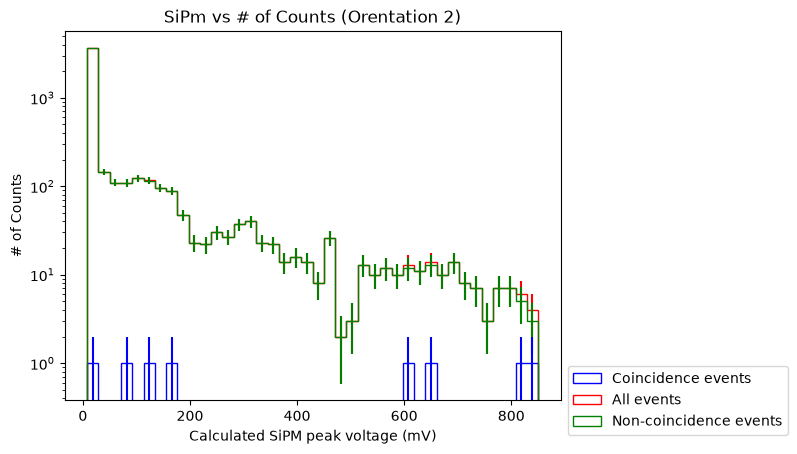

In [56]:
# Histogram shows a coincidence measurement showing the calculated SiPM peak voltage
# Use the format of plt.hist(x, bins=None, range=None, density=False, color=None, edgecolor=None) to plot a histogram of the data.
# Use histtype="step" to plot a histogram of the data with no fill.
_,sipm_bins,_ = plt.hist(fileo2.sipm[fileo2.coincidence==1], bins=40, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(fileo2.sipm, bins=sipm_bins, histtype="step", range=None, density=False, color="red", label="All events")
plt.hist(fileo2.sipm[fileo2.coincidence==0], bins=sipm_bins, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")


# Get the center of the bins and get the number of counts in each bin for all three categories

counts_all, edges = np.histogram(fileo2.sipm, bins=sipm_bins)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(fileo2.sipm[fileo2.coincidence == 0], bins=sipm_bins)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(fileo2.sipm[fileo2.coincidence == 1], bins=sipm_bins)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("# of Counts")
plt.title("SiPm vs # of Counts (Orentation 2)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.yscale("log")

plt.show()

**Create the SiPM vs # of counts graph seen above with logarithmically spaced bins**

The SiPM pulse amplitude graphs are shown using both linear and log spaced bins. The linear histogram shows the overall distribution and the log histogram uses bins spaced at log intervals, modeling graphs seen in the Cosmic Watch official paper.

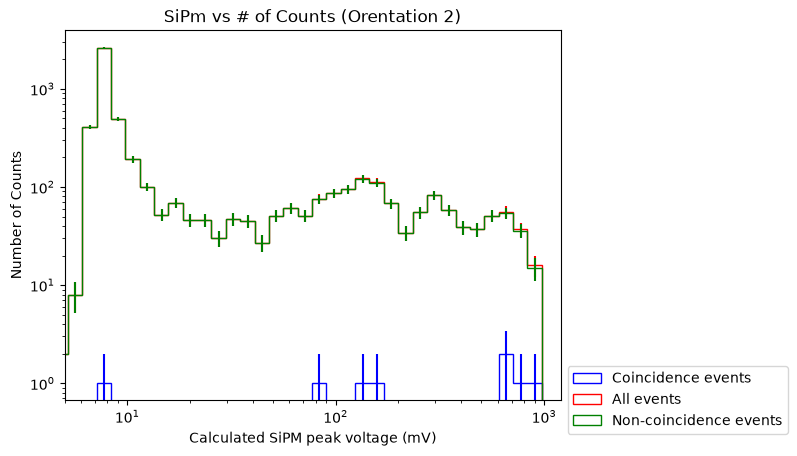

In [ ]:
# Create logarithmically spaced bins
bins_sipm = np.logspace(np.log10(fileo2.sipm.min()), np.log10(fileo2.sipm.max()), 40)

plt.hist(fileo2.sipm[fileo2.coincidence==1], bins=bins_sipm, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(fileo2.sipm, bins=bins_sipm, histtype="step", range=None, density=False, color="red", label="All events")
plt.hist(fileo2.sipm[fileo2.coincidence==0], bins=bins_sipm, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")

# Get the center of the bins and get the number of counts in each bin for all three categories
counts_all, edges = np.histogram(fileo2.sipm, bins=bins_sipm)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(fileo2.sipm[fileo2.coincidence == 0], bins=bins_sipm)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(fileo2.sipm[fileo2.coincidence == 1], bins=bins_sipm)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("Number of Counts")
plt.title("SiPm vs # of Counts (Orentation 2)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.xscale("log")
plt.yscale("log")
plt.xlim(5, 1200)
plt.show()

***
**Coincidence Rate Over Time**

For the graph below, the coincidence rate was calculated in 30-second bins to see how the rate changes over the course of the measurement. The red line shows the overall average coincidence rate.

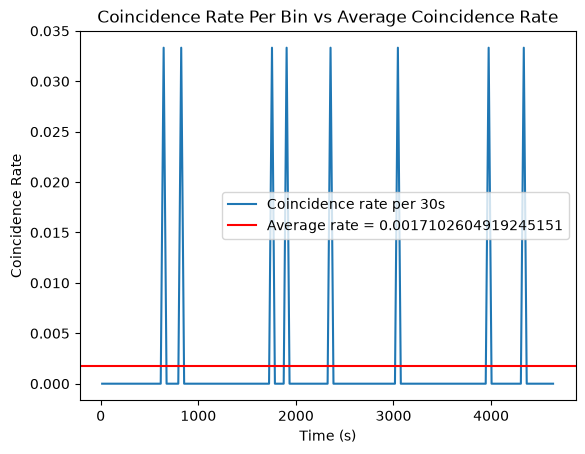

In [ ]:
bin_size = 30

# Rate of coincidences per bin (30 seconds)
coincidence_rate_per_bin = fileo2.binned_coincidence_counts / fileo2.bin_size

plt.plot(fileo2.binned_time_s, coincidence_rate_per_bin, label="Coincidence rate per 30s")

plt.axhline(o2coincidence_rate, color="red", label=f"Average rate = {o2coincidence_rate}")


plt.xlabel("Time (s)")
plt.ylabel("Coincidence Rate")
plt.title("Coincidence Rate Per Bin vs Average Coincidence Rate")
plt.legend()
plt.show()

***

### Section 5: Below is a comparison between orentation 1, orentation 2 and the regular orentation (orentation 0). 
As the solid angle between detectors increases and thereofre the coincidence rate as well.
The regular orentation is when the detectors are placed on top of eachother with the SiPM facing up.

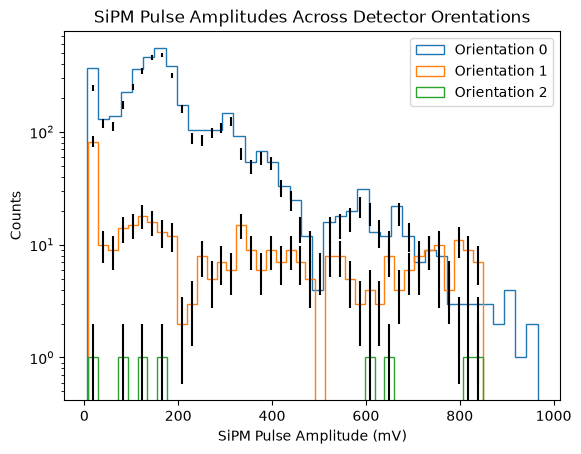

In [ ]:
_,sipm_bin,_ = plt.hist(file1.sipm[file1.coincidence==1], histtype="step", density=False, bins=40, label="Orientation 0")
# Return the amount of bins used in the first histogram and use it for the second histogram.
plt.hist(fileo1.sipm[fileo1.coincidence==1], histtype="step", bins=sipm_bins, density=False, label="Orientation 1")
plt.hist(fileo2.sipm[fileo2.coincidence==1], histtype="step", bins=sipm_bins, density=False, label="Orientation 2")


counts_c1, edges = np.histogram(file1.sipm[file1.coincidence==1], bins=sipm_bins)
xco = 0.5 * (edges[:-1] + edges[1:])  
yco = counts_c1  

counts_co1, edges = np.histogram(fileo1.sipm[fileo1.coincidence==1], bins=sipm_bins)
xco1 = 0.5 * (edges[:-1] + edges[1:])  
yco1 = counts_co1  

counts_co2, edges = np.histogram(fileo2.sipm[fileo2.coincidence==1], bins=sipm_bins)
xco2 = 0.5 * (edges[:-1] + edges[1:])  
yco2 = counts_co2       

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_1 = np.sqrt(counts_c1)
poisson_error_o1 = np.sqrt(counts_co1)
poisson_error_o2 = np.sqrt(counts_co2)

# Add Poisson error bars to the histogram bin counts. 
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(xco, yco, yerr=poisson_error_1, linestyle='none', color='black')  
plt.errorbar(xco1, yco1, yerr=poisson_error_o1, linestyle='none', color="black")  
plt.errorbar(xco2, yco2, yerr=poisson_error_o2, linestyle='none', color='black') 


plt.xlabel("SiPM Pulse Amplitude (mV)")
plt.ylabel("Counts")
plt.title("SiPM Pulse Amplitudes Across Detector Orentations")
plt.legend()
plt.yscale("log")
plt.show()

# This plot shows how the pulse amplitudes compare between the three different
# detector geometries.

**Create the SiPM vs # of counts graph seen above with logarithmically spaced bins**

The SiPM pulse amplitude graphs are shown using both linear and log spaced bins. The linear histogram shows the overall distribution and the log histogram uses bins spaced at log intervals, modeling graphs seen in the Cosmic Watch official paper.

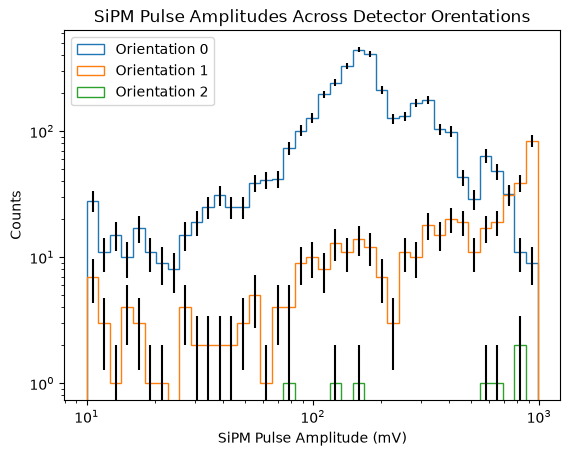

In [ ]:
# Create logarithmically spaced bins from 10 mV to the maximum pulse amplitude
sipm_bins = np.logspace(1, np.log10(max(file1.sipm.max(), fileo1.sipm.max(), fileo2.sipm.max())), 40)

# Return the amount of bins used in the first histogram and use it for the second histogram.
plt.hist(file1.sipm[file1.coincidence==1], histtype="step", bins=sipm_bins, density=False, label="Orientation 0")
plt.hist(fileo1.sipm[fileo1.coincidence==1], histtype="step", bins=sipm_bins, density=False, label="Orientation 1")
plt.hist(fileo2.sipm[fileo2.coincidence==1], histtype="step", bins=sipm_bins, density=False, label="Orientation 2")


counts_c1, edges = np.histogram(file1.sipm[file1.coincidence==1], bins=sipm_bins)
xco = 0.5 * (edges[:-1] + edges[1:])  
yco = counts_c1  

counts_co1, edges = np.histogram(fileo1.sipm[fileo1.coincidence==1], bins=sipm_bins)
xco1 = 0.5 * (edges[:-1] + edges[1:])  
yco1 = counts_co1  

counts_co2, edges = np.histogram(fileo2.sipm[fileo2.coincidence==1], bins=sipm_bins)
xco2 = 0.5 * (edges[:-1] + edges[1:])  
yco2 = counts_co2       

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_1 = np.sqrt(counts_c1)
poisson_error_o1 = np.sqrt(counts_co1)
poisson_error_o2 = np.sqrt(counts_co2)

# Add Poisson error bars to the histogram bin counts. 
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(xco, yco, yerr=poisson_error_1, linestyle='none', color='black')  
plt.errorbar(xco1, yco1, yerr=poisson_error_o1, linestyle='none', color="black")  
plt.errorbar(xco2, yco2, yerr=poisson_error_o2, linestyle='none', color='black') 


plt.xlabel("SiPM Pulse Amplitude (mV)")
plt.ylabel("Counts")
plt.title("SiPM Pulse Amplitudes Across Detector Orentations")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

# This plot shows how the pulse amplitudes compare between the three different
# detector geometries.

***

### Section 6: CW_datao3.txt (Orentation 3 in coincidence mode)
#### Loading and cleaning data, establishing coincidence mode, and SiPM vs. Time graph.
Orentation 3 is when the detectors are placed with a 6 inch block inbetween the SiPM facing sideways.

In [57]:
# As the solid angle between detectors increases and therefore the coincidence rate as well.
# This orentation will produce the smallest solid angle. 
#CW_datao3.txt is a data file that was taken with orentation 3.

import pandas as pd

# Load the data file so all 14 columns are present
datao3 = pd.read_csv("CW_datao3.txt", sep=r"\s+", skiprows=5, header=None)

# Rename the columns: 
    # Assign 2 name columns to data based the name of the device because thename is being split into two columns.

# Use for data1 when using coincidence data:
datao3.columns = [
    "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    "SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel(X:Y:Z)[g]", "Coincidence", "Name1",
    "Name", "Comp_time", "Comp_date"
]

datao3 = datao3[cols_keep]

# Save cleaned dataset as a 10-column text file with space-separated values 
# so it matches the format required by CWClass (CosmicWatch notebook)
datao3.to_csv("CW_datao3_10col.txt", sep=" ", index=False, header=False)

# Test to check column names and that the constant date column was dropped.
print(datao3.head())

    Comp_date        Comp_time  Event    Ardn_time  ADC_value  SiPM_mV  \
0  14/07/2026  09:50:56.653354    157  0:06:58.925      183.0      7.0   
1  14/07/2026  09:50:56.769573    158  0:06:59.041       61.0      7.0   
2  14/07/2026  09:50:57.333078    159  0:06:59.604      602.0      8.0   
3  14/07/2026  09:50:57.411441    160  0:06:59.683      928.0    144.0   
4  14/07/2026  09:50:58.294380    161  0:07:00.566      939.0    154.0   

   Deadtime_ms  Temp_C         Name  Coincidence  
0         8.89   26.88  Payne-Scott            0  
1         5.89   26.88  Payne-Scott            0  
2        13.85   26.88  Payne-Scott            0  
3        38.31   26.88  Payne-Scott            0  
4        39.91   26.88  Payne-Scott            0  


In [58]:
class CWClass():
    def __init__(self,fname,bin_size = 30):
        self.name = fname.split('/')[-1]
        self.bin_size = bin_size
        
        fileHandle = open(fname,"r" )
        lineList = fileHandle.readlines()
        fileHandle.close()
        header_lines = 0
        
        # Look through the first 1000 lines for the word "Device". Everything prior is considered part of the header.
        for i in range(min(len(lineList),1000)):
            header_in_file = lineList[i]
            if 'Device' in header_in_file:
                header_lines = i+1
  
        #Determine number of columns by looking at the second last line in the file.
        number_of_columns = len(lineList[len(lineList)-2].split(" "))
        column_array = range(0,number_of_columns)

        
        file_from_computer = False
        file_from_sdcard   = False
        
        if number_of_columns == 10:
            file_from_computer = True  # If you have 10 columns, you probably took the data on the computer 
            data = np.genfromtxt(fname, dtype = str, delimiter=' ', usecols=column_array, invalid_raise=False, skip_header=header_lines)
            comp_date = data[:,0] #first column of data
            comp_time = data[:,1]
            event_number = data[:,2].astype(float)
            # The column contained formatted time strings (HH:MM:SS.ms) instead of numeric values.
            # It had to be manually converted to milliseconds for processing.
            Ardn_time_ms = np.array([
                int(t.split(":")[0])*3600 +
                int(t.split(":")[1])*60 +
                float(t.split(":")[2])
                for t in data[:,3]
                ]) * 1000
            adc = data[:,4].astype(float)
            sipm = data[:,5].astype(float)
            deadtime = data[:,6].astype(float)
            temperature = data[:,7].astype(float)
            # Ensure lines say (float) instead of (np.float)
            detName = data[:,8]
            self.coincidence = data[:,9].astype(float) 


            
        elif number_of_columns == 6:
            file_from_sdcard = True # If you have 6 columns, you took the data from the sdCard
            data = np.genfromtxt(fname, dtype = str, delimiter=' ', usecols=column_array, invalid_raise=False, skip_header=header_lines)
            event_number = data[:,0].astype(np.float)
            Ardn_time_ms = data[:,1].astype(np.float)
            adc = data[:,2].astype(np.float)
            sipm = data[:,3].astype(np.float)
            deadtime = data[:,4].astype(np.float)
            temperature = data[:,5].astype(np.float)
            
        else: 
            print('The file format is unknown, or older. If it is an older file format, you will have to change the number of columns in the CW class.')
            
            
        # Simple check to see if the events are sequential
        def sequential(l):
            l = np.asarray(l).astype(int)
            check = range(min(l),max(l)+1)

            if len(l)!=len(check):
                print('There is an event missing in the data.')
                return False

            counter = 0
            for i in range(len(l)):
                counter+=1
                if l[i]!=check[i]:
                    print('Check event number: '+str(counter))
            return sum(check == l)==len(l)

        if not sequential(event_number):
            print('Events in file are not sequential.')

        # Convert the computer time to an absolute time (MJD).
        if file_from_computer:
            time_stamp = []
            for i in range(len(comp_date)):
                comp_date = [d.replace('/', '-') for d in comp_date]
                day  = int(comp_date[i].split('-')[0])
                month = int(comp_date[i].split('-')[1])
                year   = int(comp_date[i].split('-')[2])
                hour  = int(comp_time[i].split(':')[0])
                mins  = int(comp_time[i].split(':')[1])
                sec   = int(np.floor(float(comp_time[i].split(':')[2])))
                try:  
                    decimal = float('0.'+str(comp_time[i].split('.')[-1]))
                except:
                    decimal = 0.0
                time_stamp.append(float(time.mktime((year, month, day, hour, mins, sec, 0, 0, 0)))+ decimal) 


            self.time_stamp_s     = np.asarray(time_stamp) -  min(np.asarray(time_stamp))       # The absolute time of an event in seconds
            self.time_stamp_ms    = np.asarray(time_stamp -  min(np.asarray(time_stamp)))*1000  # The absolute time of an event in miliseconds   
            self.total_time_s     = max(time_stamp) -  min(time_stamp)     # The absolute time of an event in seconds
            self.detector_name    = detName                                
            self.n_detector       = len(set(detName))

        # Convert the cumulative deadtime to the deadtime between events
        # The detector starts at time 0, so append a zero.
        event_deadtime_ms = diff(np.append([0],deadtime))

        # The Arduino absolute time isn't great. Over the course of a few hours, it will be off by several seconds. 
        # The computer will give you accurate time down to about 1ms. Reading from the serial port has ~ms scale uncertainty.
        # The Arduino can give you a precise measurement (down to 1us), but the absolute time will drift. Expect it to be off by roughly 1min per day.
        from datetime import datetime
        

        self.Ardn_time_ms      = Ardn_time_ms
        self.Ardn_time_s       = Ardn_time_ms/1000.
        
        self.Ardn_total_time_s = max(self.Ardn_time_s)
        self.Ardn_total_time_ms= max(self.Ardn_time_s)*1000.

        self.event_number     = np.asarray(event_number)  # an arrray of the event numbers
        self.total_counts     = max(event_number.astype(int)) - min(event_number.astype(int))
        self.adc              = adc         # an arrray of the measured event ADC value
        self.sipm             = sipm        # an arrray of the measured event SiPM value
        
        self.event_deadtime_s   = event_deadtime_ms/1000.      # an array of the measured event deadtime in seconds
        self.event_deadtime_ms  = event_deadtime_ms            # an array of the measured event deadtime in miliseconds
        self.total_deadtime_ms  = max(event_deadtime_ms)       # an array of the measured event deadtime in miliseconds
        self.total_deadtime_s   = max(event_deadtime_ms)/1000. # The total deadtime in seconds
                
        # The time between events is well described by the Arduino timestamp. 
        # The 'diff' command takes the difference between each element in the array.
        self.Ardn_event_livetime_s = diff(np.append([0],self.Ardn_time_s)) - self.event_deadtime_s
        

 
        if file_from_computer:
            self.live_time        = (self.total_time_s - self.total_deadtime_s)
            self.weights          = np.ones(len(event_number)) / self.live_time
            self.count_rate       = self.total_counts/self.live_time 
            self.count_rate_err   = np.sqrt(self.total_counts)/self.live_time 

            bins = range(0,int(max(self.time_stamp_s)), self.bin_size)
            counts, binEdges       = np.histogram(self.time_stamp_s, bins = bins)
            coincidence, binEdges  = np.histogram(self.time_stamp_s[self.coincidence == 1], bins = bins)
            bin_livetime, binEdges = np.histogram(self.time_stamp_s, bins = bins, weights = self.Ardn_event_livetime_s)

            self.binned_coincidence_counts = coincidence
            self.binned_coincidence_rate = coincidence / bin_livetime
    
    
        elif file_from_sdcard:
            self.live_time        = (self.Ardn_total_time_ms - self.total_deadtime_ms)/1000.
            self.weights          = np.ones(len(event_number)) / self.live_time
            self.count_rate       = self.total_counts/self.live_time 
            self.count_rate_err   = np.sqrt(self.total_counts)/self.live_time 

            bins = range(int(min(self.Ardn_time_s)),int(max(self.Ardn_time_s)),self.bin_size)
            counts, binEdges = np.histogram(self.Ardn_time_s, bins = bins)
            bin_livetime, binEdges = np.histogram(self.Ardn_time_s, bins = bins, weights = self.Ardn_event_livetime_s)
            
        else:
            print('Error')
        
        print('Count rate: '+str(np.round(self.count_rate,4)) +' +/- '+ str(np.round(self.count_rate_err,4)))
        
        bincenters = 0.5*(binEdges[1:]+ binEdges[:-1])
        
        self.bin_size          = bin_size
        self.binned_counts     = counts
        self.binned_counts_err = np.sqrt(counts)
        self.binned_count_rate = counts/bin_livetime
        self.binned_count_rate_err = np.sqrt(counts)/bin_livetime
        self.binned_time_s     = bincenters
        self.binned_time_m     = bincenters/60.

    
        
def plusSTD(n,array):
    xh = np.add(n,np.sqrt(np.abs(array)))
    return xh

def subSTD(n,array):
    xl = np.subtract(n,np.sqrt(np.abs(array)))
    return xl

def fill_between_steps(x, y1, y2=0, h_align='mid', ax=None,lw=2, **kwargs):
    # If no Axes opject given, grab the current one:
    if ax is None:
        ax = plt.gca()
    # First, duplicate the x values
    xx = x.repeat(2)[1:]
    # Now: the average x binwidth
    xstep = sp.repeat((x[1:] - x[:-1]), 2)
    xstep = sp.concatenate(([xstep[0]], xstep, [xstep[-1]]))
    # Now: add one step at end of row.
    xx = sp.append(xx, xx.max() + xstep[-1])

    # Make it possible to chenge step alignment.
    if h_align == 'mid':
        xx -= xstep / 2.
    elif h_align == 'right':
        xx -= xstep

    # Also, duplicate each y coordinate in both arrays
    y1 = y1.repeat(2)#[:-1]
    if type(y2) == sp.ndarray:
        y2 = y2.repeat(2)#[:-1]

    # now to the plotting part:
    ax.fill_between(xx, y1, y2=y2,lw=lw, **kwargs)
    return ax

print('Definitions complete ...')

Definitions complete ...


In [59]:
fileo3 = CWClass(cwd + "/CW_datao3_10col.txt", bin_size=30)

o3coincidence_rate = np.sum(fileo3.coincidence) / fileo3.total_time_s
print(o3coincidence_rate)

Count rate: 1.4231 +/- 0.0095
0.001319484574161258


In [60]:
# Divide each orientation’s rate by the rate of the reference (the highest-rate orientation)
# This will convert the coincidence rates into a relative rates, allowing data collected across locations to be compared.
print("Orientation 3 rate:", o3coincidence_rate)

# Divide all home measurements by the lab reference rate
# Orentation 3 was done in the lab
o3relativerate=o3coincidence_rate/coincidence_ratelab
print("Orientation 3 relative rate:", o3relativerate)

Orientation 3 rate: 0.001319484574161258
Orientation 3 relative rate: 0.010383726216727856


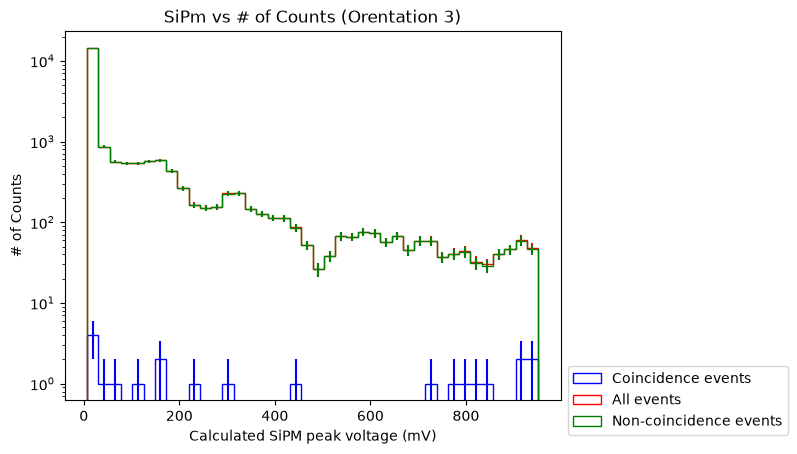

In [61]:
# Histogram shows a coincidence measurement showing the calculated SiPM peak voltage
# Use the format of plt.hist(x, bins=None, range=None, density=False, color=None, edgecolor=None) to plot a histogram of the data.
# Use histtype="step" to plot a histogram of the data with no fill.
_,sipm_bins,_ = plt.hist(fileo3.sipm[fileo3.coincidence==1], bins=40, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(fileo3.sipm, bins=sipm_bins, histtype="step", range=None, density=False, color="red", label="All events")
plt.hist(fileo3.sipm[fileo3.coincidence==0], bins=sipm_bins, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")


# Get the center of the bins and get the number of counts in each bin for all three categories

counts_all, edges = np.histogram(fileo3.sipm, bins=sipm_bins)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(fileo3.sipm[fileo3.coincidence == 0], bins=sipm_bins)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(fileo3.sipm[fileo3.coincidence == 1], bins=sipm_bins)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("# of Counts")
plt.title("SiPm vs # of Counts (Orentation 3)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.yscale("log")

plt.show()

**Create the SiPM vs # of counts graph seen above with logarithmically spaced bins**

The SiPM pulse amplitude graphs are shown using both linear and log spaced bins. The linear histogram shows the overall distribution and the log histogram uses bins spaced at log intervals, modeling graphs seen in the Cosmic Watch official paper.

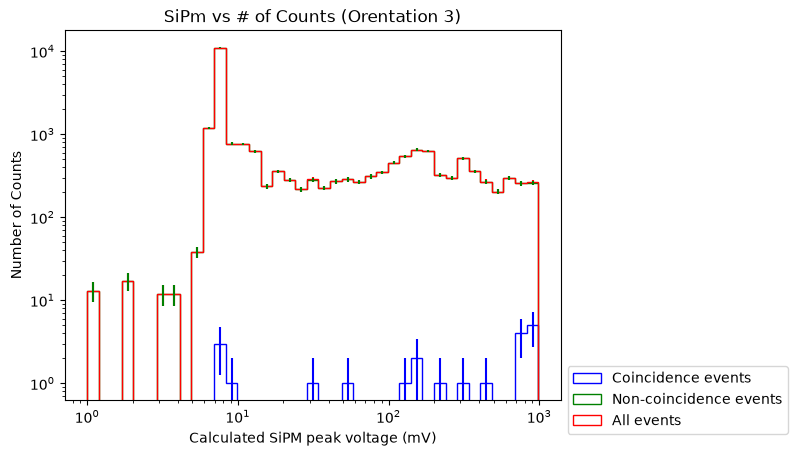

In [ ]:
# Create logarithmically spaced bins
bins_sipm = np.logspace(np.log10(fileo3.sipm.min()), np.log10(fileo3.sipm.max()), 40)

plt.hist(fileo3.sipm[fileo3.coincidence==1], bins=bins_sipm, histtype="step", range=None, density=False, color="blue", label="Coincidence events")
plt.hist(fileo3.sipm[fileo3.coincidence==0], bins=bins_sipm, histtype="step", range=None, density=False, color="green", label="Non-coincidence events")
plt.hist(fileo3.sipm, bins=bins_sipm, histtype="step", range=None, density=False, color="red", label="All events")


# Get the center of the bins and get the number of counts in each bin for all three categories
counts_all, edges = np.histogram(fileo3.sipm, bins=bins_sipm)
x = 0.5 * (edges[:-1] + edges[1:])
y = counts_all

counts_non, edges = np.histogram(fileo3.sipm[fileo3.coincidence == 0], bins=bins_sipm)
xnon = 0.5 * (edges[:-1] + edges[1:])
ynon = counts_non

counts_co, edges = np.histogram(fileo3.sipm[fileo3.coincidence == 1], bins=bins_sipm)
xco = 0.5 * (edges[:-1] + edges[1:])
yco = counts_co

# Poisson probability distribution (P(X = x) = e^(-λ) * λ^x / x!)
poisson_error_all = np.sqrt(counts_all)
poisson_error_non = np.sqrt(counts_non)
poisson_error_co = np.sqrt(counts_co)

# Add Poisson error bars to the histogram bin counts.
# The error bars are plotted at the centers without connecting lines.
plt.errorbar(x, y, yerr=poisson_error_all, linestyle='none', color='red')
plt.errorbar(xnon, ynon, yerr=poisson_error_non, linestyle='none', color="green")
plt.errorbar(xco, yco, yerr=poisson_error_co, linestyle='none', color='blue')


plt.xlabel("Calculated SiPM peak voltage (mV)")
plt.ylabel("Number of Counts")
plt.title("SiPm vs # of Counts (Orentation 3)")
plt.legend(bbox_to_anchor=(1, 0), loc="center left")
plt.xscale("log")
plt.yscale("log")
plt.show()

***
**Coincidence Rate Over Time**

For the graph below, the coincidence rate was calculated in 30-second bins to see how the rate changes over the course of the measurement. The red line shows the overall average coincidence rate.

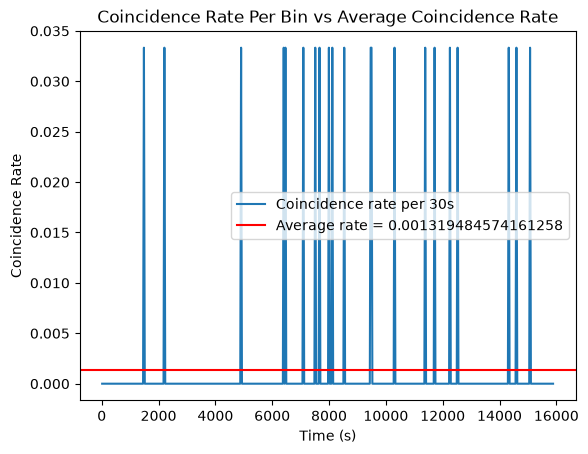

In [ ]:
bin_size = 30

# Rate of coincidences per bin (30 seconds)
coincidence_rate_per_bin = fileo3.binned_coincidence_counts / fileo3.bin_size

plt.plot(fileo3.binned_time_s, coincidence_rate_per_bin, label="Coincidence rate per 30s")

plt.axhline(o3coincidence_rate, color="red", label=f"Average rate = {o3coincidence_rate}")

plt.xlabel("Time (s)")
plt.ylabel("Coincidence Rate")
plt.title("Coincidence Rate Per Bin vs Average Coincidence Rate")
plt.legend()
plt.show()

***

### Section 7: A comparison between the coincidence rates for each orientation that faces sideways.

In [ ]:
# Coincidence rates for the different orientations of the detectors.
print("Orientation 1:", o1coincidence_rate, "Hz")
print("Orientation 2:", o2coincidence_rate, "Hz")
print("Orientation 3:", o3coincidence_rate, "Hz")

Orientation 1: 0.013231515828391058 Hz
Orientation 2: 0.0017102604919245151 Hz
Orientation 3: 0.001319484574161258 Hz


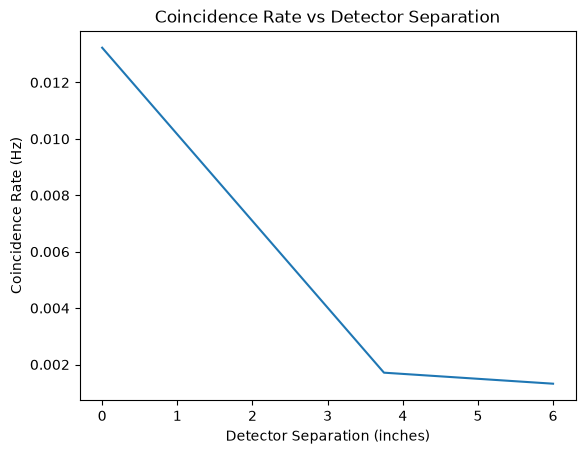

In [ ]:
separation = [0, 3.75, 6] # in inches
rates = [o1coincidence_rate, o2coincidence_rate, o3coincidence_rate]

plt.plot(separation, rates)

plt.xlabel("Detector Separation (inches)")
plt.ylabel("Coincidence Rate (Hz)")
plt.title("Coincidence Rate vs Detector Separation")


plt.show()
# As the distance between the detectors increases, the solid angle overlap decreases.
# This lessens the number of muons detected in coincidence.

### Section 8: Confirming the rate for each orentation is consistant. 
If there is a discontinuity in the data, look at the code below to examine the issue.
Large changes might show interruptions in data or detector errors.

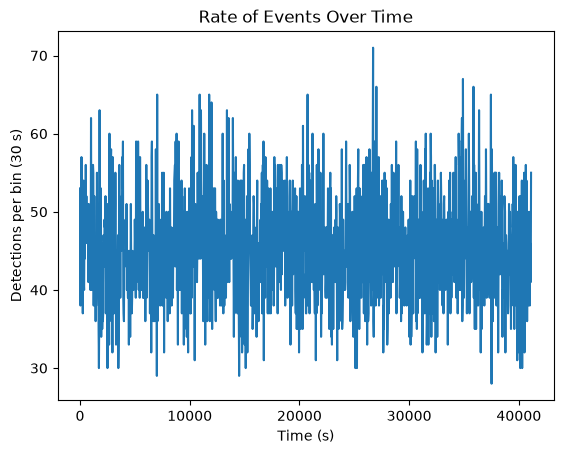

In [ ]:
# Check to see that the rate for each orentation is consistent during the run.

plt.plot(fileo1.binned_time_s, fileo1.binned_counts)
# Binned counts are the number of events that occurred in each time bin (30 seconds in this case).


plt.xlabel("Time (s)")
plt.ylabel("Detections per bin (30 s)")
plt.title("Rate of Events Over Time")
plt.show()


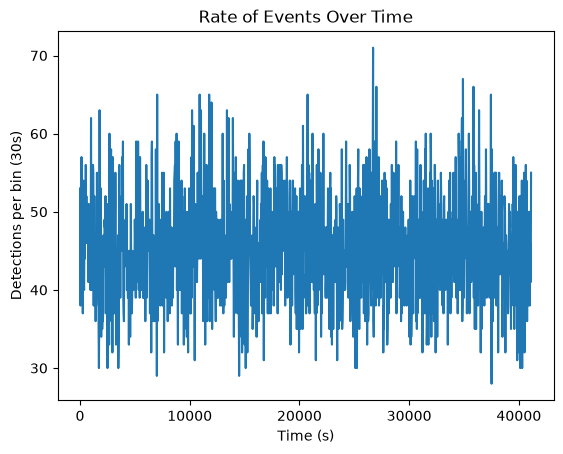

In [ ]:
# Check to see that the rate for each orentation is consistent during the run.

plt.plot(fileo1.binned_time_s, fileo1.binned_counts)
# Binned counts are the number of events that occurred in each time bin (30 seconds in this case).


plt.xlabel("Time (s)")
plt.ylabel("Detections per bin (30s)")
plt.title("Rate of Events Over Time")
plt.show()

**If there is a dip in the number of detections that occur:**

Find the time bin with the lowest number of detections and print the time and number of detections in that bin using the code below.

In [ ]:

dip = np.argmin(fileo3.binned_counts) # Find the minimum value which will show the time bin with the lowest value of counts (the dip).

print("Dip:", dip) # The time bin where the dip is.
print("Time:", fileo3.binned_time_s[dip])
print("# of Counts:", fileo3.binned_counts[dip])

In [ ]:
# If there is a discontinuity in the data, zoom in on the time range where the discontinuity occurs to see if there is a problem with the data collection.

plt.plot(fileo3.binned_time_s, fileo3.binned_counts)
plt.xlim(580, 600) # X axis limits to zoom in on the time range where the discontinuity happened.
plt.ylabel("Detections per bin (30s)")
plt.title("Rate of Events Over Time")
# This is likely due to a problem with the data collection during that time.

***

### Section 9: Checking the geometric ratio and calculating solid angle acceptance
#### When you increase the distance between detectors, fewer muons pass through both detectors, which means the coincidence rate will get smaller because the geometric overlap (solid angle acceptance) is smaller

In [51]:
# Approximate solid angle acceptance
# solid angle subtended between detectors increases
# Scintillator area (cm^2) 1 x 5 x 5 cm

def solid_angle(width, height, distance):
    theta1 = np.arctan(width / distance)
    theta2 = np.arctan(height / distance)
    return theta1 * theta2

# Width uncertainty: ±0.1 cm (tape, ruler)
# Height uncertainty: ±0.1 cm (tape, ruler)
# Distance uncertainty: ±0.2 cm (spot between detectors)


#1: 
# 4 cm from top surface to top surface minus the thickness of the top scintillator (1 cm)
# Therefore, D=3 cm
solid_angle0 = solid_angle(5, 5, 3)

# o1: 1 cm * 2 from edge to scintillator
# D = 2
solid_angle1 = solid_angle(5, 1, 2)

# o2: 3.75 inch * 2.54 cm/inch = 9.525 cm 
#  1 cm * 2 from edge to scintillator
# D = 11.525
solid_angle2 = solid_angle(5, 1, 11.525)

# o3: 6 inch * 2.54 cm/inch = 15.34 cm 
#  1 cm * 2 from edge to scintillator
# D = 17.34
solid_angle3 = solid_angle(5, 1, 17.34)

#2 inch block: 2 inches * 2.54 cm = 5.08 
# The block (5.08 cm) plus the original 3 cm inbetween
solid_angle_2inch = solid_angle(5, 5, 8.08)

# 2.54 cm (1 inch block) + 3 = 5.54 cm
solid_angle_test = solid_angle(5, 5, 5.54)
print(solid_angle_test)

# Define solid_angles as the solid angles rates calculated for each orentation
solid_angles = np.array([
    solid_angle0,
    solid_angle1,
    solid_angle_2inch,
    solid_angle2,
    solid_angle3
])

# Define relative_rates as the relatives rates calculated for each orentation
relative_rates = np.array([
    1,
    o1relativerate,
    inchrelative_rate,
    o2relativerate,
    o3relativerate
])

0.5390636239480072


NameError: name 'o2relativerate' is not defined

The next two cells are used to find the error of the coincidence rate and solid angle for each orentation.

In [ ]:
# To find error of each solid angle: 

w = 0.1   # Width uncertainty: ±0.1 cm (tape, ruler)
h = 0.1   # Height uncertainty: ±0.1 cm (tape, ruler)
d = 0.3   # Distance uncertainty: ±0.2 cm (spot between detectors)

def solid_angle_error(width, height, distance):
    angle_width = (solid_angle(width + w, height, distance) - solid_angle(width - w, height, distance)) / (2 * w)

    angle_height = (solid_angle(width, height + h, distance) - solid_angle(width, height - h, distance)) / (2 * h)

    angle_distance = (solid_angle(width, height, distance + d)- solid_angle(width, height, distance - d)) / (2 * d)

    return np.sqrt(
        (angle_width * w)**2 +
        (angle_height * h)**2 +
        (angle_distance * d)**2
    )


solid_angle0_error = solid_angle_error(5, 5, 3)
solid_angle1_error = solid_angle_error(5, 1, 1.5)
solid_angle2_error = solid_angle_error(5, 1, 11.025)
solid_angle3_error = solid_angle_error(5, 1, 16.84)
solid_angle_2inch_error = solid_angle_error(5, 5, 8.08)

solid_angle_errors = np.array([
    solid_angle0_error,
    solid_angle1_error,
    solid_angle_2inch_error,
    solid_angle2_error,
    solid_angle3_error
])


In [ ]:
# To find error of each coincidence rate: 
# Use Poisson statistics (√N) for the coincidence counts, and ivide by time to to convert uncertainty from counts to coincidence rate 
o0_error = np.sqrt(sum(file1.coincidence)) / file1.total_time_s
o1_error = np.sqrt(sum(fileo1.coincidence)) / fileo1.total_time_s
o2_error = np.sqrt(sum(fileo2.coincidence)) / fileo2.total_time_s
o3_error = np.sqrt(sum(fileo3.coincidence)) / fileo3.total_time_s

inch_error = np.sqrt(sum(file2inch.coincidence)) / file2inch.total_time_s

# Relative error
o0relative_error = o0_error / coincidence_rate # done at home
o1relative_error = o1_error / coincidence_rate # done at home
o2relative_error = o2_error / coincidence_ratelab
o3relative_error = o3_error / coincidence_ratelab
inch_relative_error = inch_error / coincidence_ratelab

relative_errors = np.array([
    o0relative_error, 
    o1relative_error,
    inch_relative_error,
    o2relative_error,
    o3relative_error
])

**Create a table including all detector orientations to compare coincidence rate, distance, uncertainty, and solid angle.**

In [ ]:
data = {
    "Orentation discription": ["Stacked", "Stacked with 2 inch block", "Sideways Stacked", "Sideways Stacked with 3.75 inch block", "Sideways Stacked with 6 inch block"],
    "Orientation": ["O0", "2 inch block", "O1", "O2", "O3"],
    "Distance (cm)": [5, 8.08, 2, 11.525, 17.34],
    "Average Rate (Hz)": [coincidence_rate, inchcoincidence_rate, o1coincidence_rate, o2coincidence_rate, o3coincidence_rate],
    "Rate Uncertainty (Hz)": [
        o0_error,
        inch_error,
        o1_error,
        o2_error,
        o3_error
    ],
    "Rate Relative to Max": [
        1,
        inchrelative_rate,
        o1relativerate,
        o2relativerate,
        o3relativerate
    ],
    "Approximate solid angle": [solid_angle0, solid_angle_2inch, solid_angle1, solid_angle2, solid_angle3],
}

table = pd.DataFrame(data)
table


,Orentation discription,Orientation,Distance (cm),Average Rate (Hz),Rate Uncertainty (Hz),Rate Relative to Max,Approximate solid angle
0,Stacked,O0,5.000,0.099604,0.001619,1.000000,1.061676
1,Stacked with 2 inch block,2 inch block,8.080,0.032306,0.000896,0.324345,0.307068
2,Sideways Stacked,O1,2.000,0.013232,0.000585,0.132841,0.551875
3,Sideways Stacked with 3.75 inch block,O2,11.525,0.001710,0.000605,0.013459,0.035428
4,Sideways Stacked with 6 inch block,O3,17.340,0.001319,0.000288,0.010384,0.016172


**Note on the relationship between rates and solid angle:**

The expected relationship was that coincidence rate would increase with solid angle because a larger  area allows more muons to be detected. However, the measured rates did not follow this for every orentation, which suggests that the simple solid angle calculation has limits.

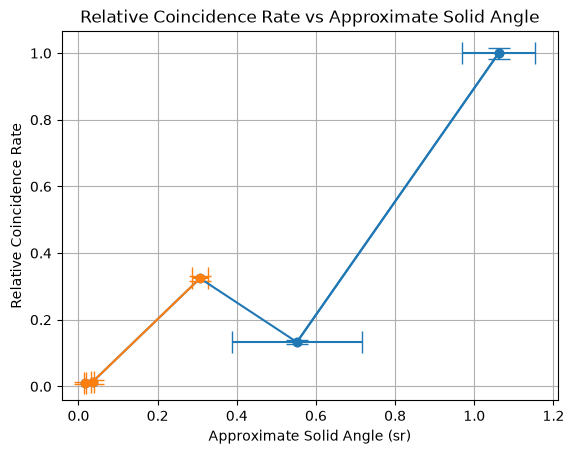

In [ ]:
# Orentations where the face is sideways = blue
plt.errorbar(
    solid_angles[:2],
    relative_rates[:2],
    xerr=solid_angle_errors[:2],
    yerr=relative_errors[:2],
    fmt="o-",
    color="tab:blue",
    capsize=8,
    label="Facing Up"
)

# Orentations where the face faces up = orange
plt.errorbar(
    solid_angles[2:],
    relative_rates[2:],
    xerr=solid_angle_errors[2:],
    yerr=relative_errors[2:],
    fmt="o-",
    color="tab:orange",
    capsize=8,
    label="Sideways"
)
plt.plot(solid_angles, relative_rates, "o-")
plt.xlabel("Approximate Solid Angle (sr)")
plt.ylabel("Relative Coincidence Rate")
plt.title("Relative Coincidence Rate vs Approximate Solid Angle")
plt.grid(True)
plt.show()

***

### Section 10: This section compares four Orientation 0 detector separations (0 cm, 2-inch (5.08 cm), 3.5-inch (8.89 cm), and 12 cm)
#### Seeing the relationship between coincidence rate and solid angle while keeping the detector faces the same direction.
Using orentation 0, orentation 0 with a 2 inch block (5.08 cm), orentation 0 with 3.5 inch (8.89 cm), and orentation 0 with 12 cm.

In [42]:
# Load CW_data35.txt and CW_data12.txt (O0 and O0 with the 2 inch block should already be loaded and cleaned)

import pandas as pd
data35 = pd.read_csv("CW_data35.txt", sep=r"\s+", skiprows=5, header=None) # 3.5 inches
data12 = pd.read_csv("CW_data12.txt", sep=r"\s+", skiprows=5, header=None) # 12 cm

data35.columns = [
    "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    "SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel(X:Y:Z)[g]", "Coincidence", 
    "Name1", "Name", "Comp_time", "Comp_date"
]

cols_keep = [
    "Comp_date",
    "Comp_time",
    "Event",
    "Ardn_time",
    "ADC_value",
    "SiPM_mV",
    "Deadtime_ms",
    "Temp_C",
    "Name",
    "Coincidence"
]

data35 = data35[cols_keep]
data35.to_csv("CW_data_10col35.txt", sep=" ", index=False, header=False)

data12.columns = [
    "Event", "Ardn_time", "2019", "Flag", "ADC_value", 
    "SiPM_mV", "Deadtime_ms", "Temp_C", "Press_Pa", "Accel(X:Y:Z)[g]", "Coincidence", 
    "Name1", "Name", "Comp_time", "Comp_date"
]
cols_keep = [
    "Comp_date",
    "Comp_time",
    "Event",
    "Ardn_time",
    "ADC_value",
    "SiPM_mV",
    "Deadtime_ms",
    "Temp_C",
    "Name",
    "Coincidence"
]

data12 = data12[cols_keep]
data12.to_csv("CW_data_10col12.txt", sep=" ", index=False, header=False)



In [43]:
# Find the coincidence rate for both orentations.
# Note: Both orentations were recorded in the lab.

# Load data that was taken from a computer
cwd = os.getcwd()

file35 = CWClass(cwd + "/CW_data_10col35.txt", bin_size = 30)
coincidence_rate35 = sum(file35.coincidence) / file35.total_time_s

file12 = CWClass(cwd + "/CW_data_10col12.txt", bin_size = 30)
coincidence_rate12 = sum(file12.coincidence) / file12.total_time_s

# Divide each orientation’s rate by the rate of the reference (the highest-rate orientation)
relativerate35=(coincidence_rate35/coincidence_ratelab)
relativerate12=(coincidence_rate12/coincidence_rate)
print(coincidence_rate35)


Count rate: 1.5151 +/- 0.011
Count rate: 1.4454 +/- 0.0117
0.018451626323849803


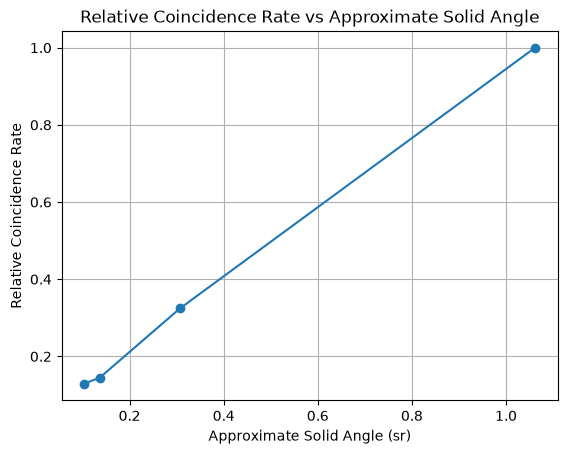

In [62]:
# Relative coincidence rates for all orentations
relative_rates = [
    1,
    inchrelative_rate,
    relativerate35,
    relativerate12,
   ]

# Find solid angles for the 3.5 inch (8.89 cm) cm and 12 cm orentations 

def solid_angle(width, height, distance):
    theta1 = np.arctan(width / distance)
    theta2 = np.arctan(height / distance)
    return theta1 * theta2

solid_angle35 = solid_angle(5, 5, 12.89) # 3.5 inches (8.89 cm) + 3 cm = 12.89 cm
solid_angle12 = solid_angle(5, 5, 15) # 12 cm + 3 cm = 15 cm

# Solid angles for all orentations
solid_angles = [
    solid_angle0,
    solid_angle_2inch,
    solid_angle35,
    solid_angle12
]

plt.plot(solid_angles, relative_rates, "o-")
plt.xlabel("Approximate Solid Angle (sr)")
plt.ylabel("Relative Coincidence Rate")
plt.title("Relative Coincidence Rate vs Approximate Solid Angle")
plt.grid(True)
plt.show()

### Section 11: Future Experiments
If I had more time with the detectors, I would have tilted the detectors at an angle, similar to the geometry of a muon telescope. Since the rate of muons depends on the angle at which they are hitting the detector, measuring the rate at several tilt angles would be helpful to analyze the angular impact of muon flux. 

Another experiment would be to completely shield the detectors with lead. In this notebook, lead blocks were either placed between the detectors or placed around with slight openings. To further minimize background radiation, the detectors could be completely covered. Comparing measurements with and without full coverage would help show how effective the lead is at isolating muon events. 